In [1]:
# Top of notebook
%config InlineBackend.figure_formats = ['jpeg']
%config InlineBackend.rc = {'figure.dpi': 100}

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors  
from rdkit.Chem import Lipinski
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

import pubchempy as pcp
#from IPython.display import Imag

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from sklearn.preprocessing import StandardScaler
#from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn import metrics
#from sklearn.ensemble import RandomForestRegressor

#import torch
from scipy import stats
import os

import joblib
import json

from tqdm import tqdm


# Data collection (skip if needed)
This part creates modeling_results.csv, which contains all the energy data needed. If the file exists, this section can be skipped.

In [ ]:
table_names_smiles = pd.read_csv('data/solvent_name_SMILES_table.csv')#, sep='|')
table_names_smiles = table_names_smiles.set_index('Solvent Name')

table_names_smiles

In [ ]:
solvent_names_c16 = pd.read_csv('data/results-smd-001-c16.log', sep='|')
solvent_names_c18dec = pd.read_csv('data/results-smd-002-c18-octadecanol.log', sep='|')
solvent_names_c18ole = pd.read_csv('data/results-smd-003-c18-oleyl.log', sep='|')

# Remove some unwanted space
solvent_names_c16.columns = solvent_names_c16.columns.str.strip()
solvent_names_c16['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c16['Solvent Name']]
solvent_names_c18dec.columns = solvent_names_c18dec.columns.str.strip()
solvent_names_c18dec['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c18dec['Solvent Name']]
solvent_names_c18ole.columns = solvent_names_c18ole.columns.str.strip()
solvent_names_c18ole['Solvent Name'] = [ s.strip()[1:-1] for s in solvent_names_c18ole['Solvent Name']]

solvent_names_c16 = solvent_names_c16.set_index('Solvent Name')
solvent_names_c18dec = solvent_names_c18dec.set_index('Solvent Name')
solvent_names_c18ole = solvent_names_c18ole.set_index('Solvent Name')

display(solvent_names_c16, solvent_names_c18dec, solvent_names_c18ole)

In [ ]:
# Merge data into one df
solvent_names_c16 = solvent_names_c16.drop(columns='JobID')
solvent_names_c18dec = solvent_names_c18dec.drop(columns='JobID')
solvent_names_c18ole = solvent_names_c18ole.drop(columns='JobID')

solvent_names_c16 = solvent_names_c16.add_suffix('_c16')
solvent_names_c18dec = solvent_names_c18dec.add_suffix('_d18')
solvent_names_c18ole = solvent_names_c18ole.add_suffix('_o18')

df_solvent_merged = pd.concat([table_names_smiles, solvent_names_c16, solvent_names_c18dec, solvent_names_c18ole], axis=1, join='inner')

df_solvent_merged

In [ ]:
# Other compunds
logs = [ os.path.join('data',f) for f in os.listdir('data') if 'energy-smd-' in f]

name_dict = {'energy-smd-beta-carotene.log': 'bcr',
             'energy-smd-diacylgycerol.log': 'dcg',
             'energy-smd-phosphotidylcholine_c18_c181.log': 'pcc',
             'energy-smd-phosphotidylcholine_short.log': 'pcs',
             'energy-smd-triolein.log': 'tro',
             'energy-smd-tristearin.log': 'trs',
            }

for log in logs:
    mol_name = name_dict[ os.path.basename(log) ]

    data = []
    with open(log,'r') as f1:
        lines = f1.readlines()
    for line in lines:
        line = line.replace('FINAL SINGLE POINT ENERGY','|').replace('SMDSOLVENT','')
        line = line.split('|')
        solvent_name = line[0].strip()[1:-1] # use [1:-1] to remove double quote sign
        energy_value = float(line[1])
        data.append( [ solvent_name , energy_value ] )
    df = pd.DataFrame(data, columns=['Solvent Name', 'Free Energy_'+mol_name]).set_index('Solvent Name')
    df_solvent_merged = df_solvent_merged.join(df, how='inner')
    
df_solvent_merged

In [ ]:
new_col = { col: 'dG'+col[-4:]+'(kcal/mol)' for col in df_solvent_merged.columns if 'Free Energy_' in col }
Eh_to_kcalmol = 627.509

for col, new in new_col.items():
    G_water = df_solvent_merged[ df_solvent_merged['SMILES']=='O' ][col].values[0]
    deltaG = (df_solvent_merged[col] - G_water)*Eh_to_kcalmol
    df_solvent_merged[new] = deltaG

df_solvent_merged

In [ ]:
# Add previous BDO
df1 = pd.read_csv('../Diol/results_bdo_with_SMILES.csv', sep=',').set_index('Solvent Name')
df2 = pd.read_csv('../Diol/results_wat_with_SMILES.csv', sep=',').set_index('Solvent Name')

df1 = df1.rename(columns={'deltaG_Sol-Wat(kcal/mol)': 'dG_bdo(kcal/mol)'})
df2 = df2.rename(columns={'deltaG_Sol-Wat(kcal/mol)': 'dG_wat(kcal/mol)'})
    
df_solvent_merged = df_solvent_merged.join(df1['dG_bdo(kcal/mol)'], how='inner')
df_solvent_merged = df_solvent_merged.join(df2['dG_wat(kcal/mol)'], how='inner')
df_solvent_merged

In [ ]:
df_solvent_merged = df_solvent_merged.drop(columns=[ c for c in df_solvent_merged.columns if 'Energy' in c ])
df_solvent_merged.to_csv('calculation_results.csv') #, index=False)
df_solvent_merged

# Data loading

In [3]:
# Convert header to molecule name
header_to_name = {'c16':'1-Hexadecanol',
                  'd18':'1-Octadecanol',
                  'o18':'Oleyl alcohol',
                  'bcr':'Beta-carotene',
                  'dcg':'Diacylglycerol',
                  'pcc':'Phosphotidylcholine \nC18 C18:1',
                  'pcs':'Phosphotidylcholine \nshort chain',
                  'tro':'Triolein',
                  'trs':'Tristearin',
                  'bdo':'2,3-Butanediol',
                  'wat':'Water'
                 }

df_solvent_merged = pd.read_csv('data/calculation_results.csv')
df_solvent_merged = df_solvent_merged.set_index('Solvent Name')

df_solvent_merged

,SMILES,Solvent Inchi,dG_c16(kcal/mol),dG_d18(kcal/mol),dG_o18(kcal/mol),dG_bcr(kcal/mol),dG_dcg(kcal/mol),dG_pcc(kcal/mol),dG_pcs(kcal/mol),dG_tro(kcal/mol),dG_trs(kcal/mol),dG_bdo(kcal/mol),dG_wat(kcal/mol)
Solvent Name,,,,,,,,,,,,,
DIIODOMETHANE,C(I)I,InChI=1S/CH2I2/c2-1-3/h1H2,-3.356659,-3.851186,-3.475615,-13.412034,-6.851700,8.602645,22.898385,-16.593886,-17.367485,4.371604,4.804874
CIS-DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.398795,-8.730589,-7.653815,-21.086064,-14.884521,10.668876,34.355792,-29.464011,-31.256869,4.271077,5.743013
N-HEXADECANE,CCCCCCCCCCCCCCCC,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,-7.677937,-9.167254,-8.006268,-21.516200,-15.547273,11.358207,35.877781,-30.474694,-32.443510,4.251875,5.815026
N-PENTADECANE,CCCCCCCCCCCCCCC,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,-7.586496,-9.221653,-8.039168,-21.603576,-15.660476,11.285619,35.907704,-30.642798,-32.623452,4.236062,5.812930
DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.367834,-8.943202,-7.843354,-21.386239,-15.265404,10.354026,34.376695,-30.030382,-31.856118,4.214727,5.731278
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,CC(C)CO,"InChI=1S/C4H10O/c1-4(2)3-5/h4-5H,3H2,1-2H3",-11.648657,-13.039261,-12.230646,-21.124441,-23.292579,-23.764192,0.190253,-36.208227,-37.833736,-1.708895,0.321554
2-PROPANOL,CC(C)O,"InChI=1S/C3H8O/c1-3(2)4/h3-4H,1-2H3",-11.785736,-13.256033,-12.441420,-21.391541,-23.770065,-23.977015,-0.246278,-37.051997,-38.826980,-1.755833,0.321705
1-PROPANOL,CCCO,"InChI=1S/C3H8O/c1-2-3-4/h4H,2-3H2,1H3",-11.464696,-12.888062,-12.193949,-20.788446,-22.959329,-24.033361,-0.587601,-35.618125,-37.181364,-1.790283,0.236922


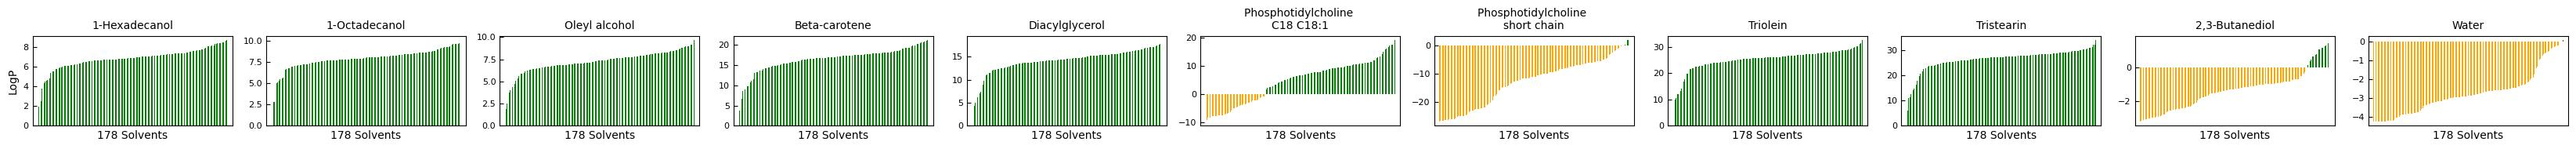

In [4]:
## If we only plot Molecule at T
dG_names = [ col for col in df_solvent_merged.columns if 'dG_' in col ]
y_names = [ header_to_name[ m[3:6] ] for m in dG_names ]
Temp_C = 25

x = np.arange(len(df_solvent_merged))

fig, axs = plt.subplots(1,len(dG_names),figsize=(3*len(dG_names),2), tight_layout=True, dpi=100)

for n,dg in enumerate(dG_names):
    df = df_solvent_merged.sort_values(dg, ascending=False) #.reset_index(drop=True)
    y = df[dg]
    y = -y/(2.303*1.987*0.001*(273.15+Temp_C))

    m = df.index #['Solvent Name']
    idx_water = np.where(m=='WATER')[0][0]
    colors = np.array(['gray' if i==idx_water else 
                       'orange' if  i<idx_water else
                       'g' for i in range(len(x))])
    
    axs[n].bar(x,y, color=colors, width=0.5)  

    axs[n].set_title( f'{y_names[n]}', fontsize=10 )
    axs[n].set_xlabel('178 Solvents',fontsize=10) ## input X name
    #axs[n].set_ylabel('LogP', fontsize=10) ## input Y name
    axs[n].tick_params(direction='in',labelsize='8')
    #axs.plot([-100,1000], [y[idx_water] ,y[idx_water] ], '--', color='gray', lw=1)
    xlim = [ np.amin(x)-5, np.amax(x)+5 ]
    axs[n].set_xlim(xlim)
    #axs[n].set_ylim([0,10.5])
    axs[n].set_xticks([])

    #print(n, dg)
    #display( y[m == '1-OCTANOL'] )

#axs[-1].set_xlabel('178 Solvents',fontsize=10) ## input X name  
axs[0].set_ylabel('LogP', fontsize=10) ## input Y name
#axs[0].plot( df_solvent_merged['dG_c16(kcal/mol)'] , df_solvent_merged['dG_d18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 
#axs[1].plot( df_solvent_merged['dG_c16(kcal/mol)'] , df_solvent_merged['dG_o18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 
#axs[2].plot( df_solvent_merged['dG_d18(kcal/mol)'] , df_solvent_merged['dG_o18(kcal/mol)'], color='r', marker='o', ls=' ', lw='2', markerfacecolor='none', markeredgecolor='r', markersize=6, ) 

#plt.savefig('logP_merge.png', dpi=800)
plt.show()

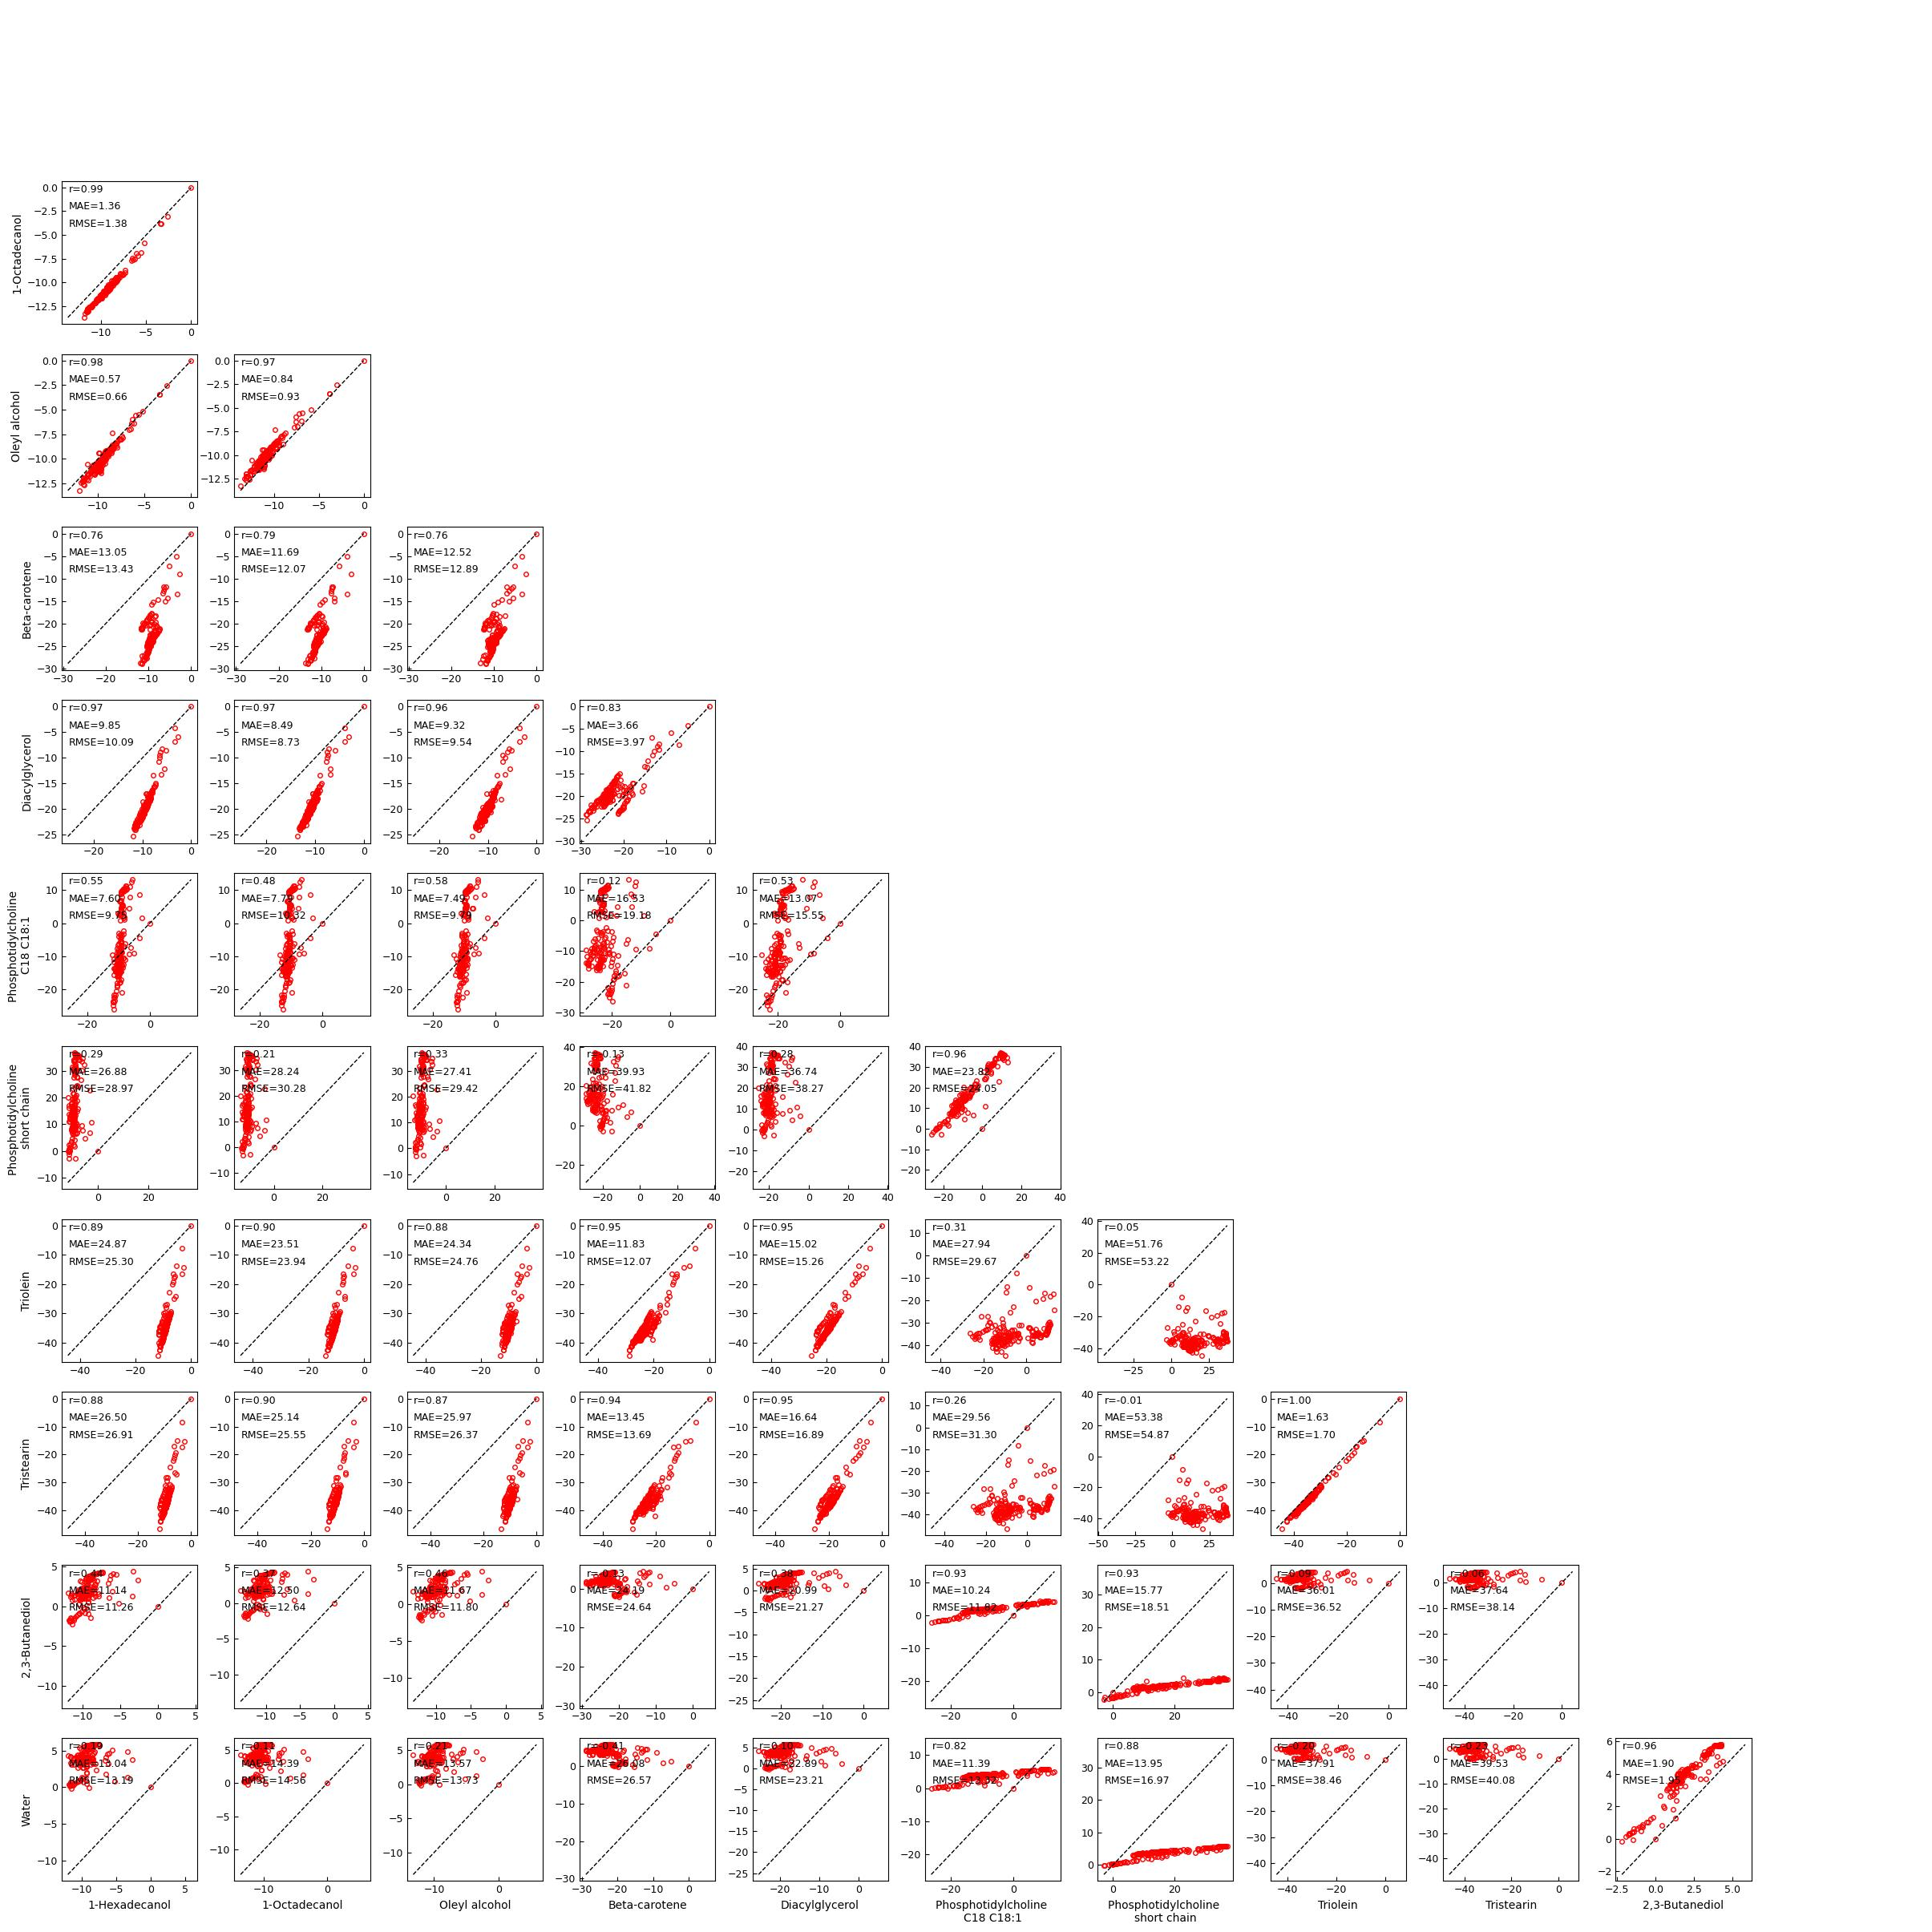

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

cols = [ col for col in df_solvent_merged.columns if 'dG_' in col ]
n = len(cols)

labels = [c.replace('dG_', '').replace('(kcal/mol)', '') for c in cols]
labels = [ header_to_name[b] for b in labels ]

fig, axs = plt.subplots(n, n, figsize=(2.2*n, 2.2*n), dpi=100, tight_layout=True)

for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        if j >= i:
            # upper triangle + diagonal: hide (or use diagonal for histograms if you want)
            ax.axis('off')
            continue

        x = df_solvent_merged[cols[j]]
        y = df_solvent_merged[cols[i]]

        ax.plot(x, y, color='r', lw=2, ls='', marker='o', ms=4, markerfacecolor='None', markeredgecolor='r')
        ax_min, ax_max = np.min((x, y)), np.max((x, y))
        ax.plot([ax_min, ax_max], [ax_min, ax_max], color='k', lw=1, ls='--')

        # Pearson correlation coefficient
        r = np.corrcoef(x, y)[0, 1]
        mae = np.mean(np.abs(x - y))
        rmse = np.sqrt(np.mean((x - y) ** 2))

        ax.text(0.05, 0.92, f'r={r:.2f}', transform=ax.transAxes, fontsize=9)
        ax.text(0.05, 0.80, f'MAE={mae:.2f}', transform=ax.transAxes, fontsize=9)
        ax.text(0.05, 0.68, f'RMSE={rmse:.2f}', transform=ax.transAxes, fontsize=9)

        ax.tick_params(direction='in', labelsize=9)
        # Only label outer axes to avoid clutter
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=10)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=10)

#plt.savefig('Compare_dG_all_pairs.png', dpi=300)
plt.show()

# Known experimental result

In [ ]:
""" 
For a non-ionizable compound like cetyl alcohol, which remains neutral regardless of pH, the partition coefficient (log P) is equal to the distribution coefficient (log D)

1-hexadecanol
c16 - XLogP3 = 7.3, https://pubchem.ncbi.nlm.nih.gov/compound/Cetyl-Alcohol#section=Depositor-Supplied-Synonyms
Partition coefficient log Pow: 6.73 at 25°C/77°F: https://atomscientific.com/product/cetyl-alcohol#:~:text=Initial%20boiling%20point%20and%20range,HS%20Code%20/%20Commodity%20Code:%2034049090
[?] Exp logP 7.21: https://doi.org/10.1556/JPC.23.2010.3.6

1-OCTADECANOL
Octadecan-1-ol
d18 - XLogP3 = 8.4, https://pubchem.ncbi.nlm.nih.gov/compound/8221#section=Depositor-Supplied-Synonyms

OLEYL ALCOHOL
o18 - XLogP3 = 7.4, https://pubchem.ncbi.nlm.nih.gov/compound/5284499

"""

# Data and feature preparation 

In [4]:
%%capture --no-display

# If needed
df = df_solvent_merged.copy() #.rename(columns={"deltaG_bdo": "deltaG_monomer"})

from rdkit.ML.Descriptors import MoleculeDescriptors

fp_names_prop = [ n[0] for n in Descriptors._descList if not n[0].startswith('fr_')]
fp_names_prop.remove('Ipc')  ## https://github.com/rdkit/rdkit/issues/1527
print( len(fp_names_prop) )

calc = MoleculeDescriptors.MolecularDescriptorCalculator(fp_names_prop)

fp_data = []
for smi in df['SMILES']:
    try:
        fp = calc.CalcDescriptors( Chem.MolFromSmiles(smi) )
        fp_data.append( list(fp) )
    except:
        print(smi, 'has problem')

df_features_prop = pd.DataFrame(fp_data, columns=fp_names_prop, index=df.index)
#df_WatSol_features_prop.to_csv('df_WatSol_features_prop.csv')
#X_features_prop = X_features_prop.dropna(axis='columns')
df_features_prop

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
DIIODOMETHANE,2.275000,2.275000,1.190000,1.190000,0.463980,6.000,267.835,265.819,267.824596,20,...,0,0,0,0,0,0,5.143867,0,1.8139,32.9070
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,13,0,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,12,0,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,1,0,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,1,0,0,0,0,0,2.930400,0,0.3887,17.3768


In [5]:
%%capture --no-display

good_elements = ['C','H','O','N',]#'S']#,'P']
mask_element = []   ## molecules to keep, keep=True
for smi in df['SMILES']:
    mol = Chem.MolFromSmiles( smi )
    element = set([at.GetSymbol() for at in mol.GetAtoms()])  ## GetSymbol , GetAtomicNum
    if all(e in good_elements for e in element):
        mask_element.append(True)
    else:
        mask_element.append(False)

solvation_data = df[mask_element]
#df_watsol = df_watsol.reset_index(drop=True)
df_features_prop = df_features_prop[mask_element]

display( df_features_prop, solvation_data )

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,13,0,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,12,0,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,2,0,2,0,0,1.967279,2,3.3668,43.9160
N-DODECANE,2.279016,2.279016,1.370868,1.370868,0.430464,10.500,170.340,144.132,170.203451,74,...,9,0,0,0,0,0,11.000000,0,4.9272,57.5180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,1,0,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,1,0,0,0,0,0,2.930400,0,0.3887,17.3768


,SMILES,Solvent Inchi,dG_c16(kcal/mol),dG_d18(kcal/mol),dG_o18(kcal/mol),dG_bcr(kcal/mol),dG_dcg(kcal/mol),dG_pcc(kcal/mol),dG_pcs(kcal/mol),dG_tro(kcal/mol),dG_trs(kcal/mol),dG_bdo(kcal/mol),dG_wat(kcal/mol)
Solvent Name,,,,,,,,,,,,,
CIS-DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.398795,-8.730589,-7.653815,-21.086064,-14.884521,10.668876,34.355792,-29.464011,-31.256869,4.271077,5.743013
N-HEXADECANE,CCCCCCCCCCCCCCCC,InChI=1S/C16H34/c1-3-5-7-9-11-13-15-16-14-12-1...,-7.677937,-9.167254,-8.006268,-21.516200,-15.547273,11.358207,35.877781,-30.474694,-32.443510,4.251875,5.815026
N-PENTADECANE,CCCCCCCCCCCCCCC,InChI=1S/C15H32/c1-3-5-7-9-11-13-15-14-12-10-8...,-7.586496,-9.221653,-8.039168,-21.603576,-15.660476,11.285619,35.907704,-30.642798,-32.623452,4.236062,5.812930
DECALIN,C1CCC2CCCCC2C1,InChI=1S/C10H18/c1-2-6-10-8-4-3-7-9(10)5-1/h9-...,-7.367834,-8.943202,-7.843354,-21.386239,-15.265404,10.354026,34.376695,-30.030382,-31.856118,4.214727,5.731278
N-DODECANE,CCCCCCCCCCCC,InChI=1S/C12H26/c1-3-5-7-9-11-12-10-8-6-4-2/h3...,-8.021134,-9.522775,-8.380471,-22.026256,-16.201210,10.890578,36.000852,-31.448621,-33.481040,4.159443,5.800304
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,CC(C)CO,"InChI=1S/C4H10O/c1-4(2)3-5/h4-5H,3H2,1-2H3",-11.648657,-13.039261,-12.230646,-21.124441,-23.292579,-23.764192,0.190253,-36.208227,-37.833736,-1.708895,0.321554
2-PROPANOL,CC(C)O,"InChI=1S/C3H8O/c1-3(2)4/h3-4H,1-2H3",-11.785736,-13.256033,-12.441420,-21.391541,-23.770065,-23.977015,-0.246278,-37.051997,-38.826980,-1.755833,0.321705
1-PROPANOL,CCCO,"InChI=1S/C3H8O/c1-2-3-4/h4H,2-3H2,1H3",-11.464696,-12.888062,-12.193949,-20.788446,-22.959329,-24.033361,-0.587601,-35.618125,-37.181364,-1.790283,0.236922


In [8]:
## Remove data column with std=0
def clean_std(df):
    print('Before clean', df.shape )
    #X_features.loc[ :, X_features.std() > X_features.mean() ]
    df_new = df.loc[ :, df.std()>0 ]
    print('After clean', df_new.shape )
    return df_new


numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_features_prop = df_features_prop.copy().select_dtypes(include=numerics)

df_features_prop = clean_std( df_features_prop )
df_features_prop

Before clean (130, 131)
After clean (130, 121)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumHeterocycles,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR
Solvent Name,,,,,,,,,,,,,,,,,,,,,
CIS-DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,0,2,0,2,0,1.967279,2,3.3668,43.9160
N-HEXADECANE,2.290220,2.290220,1.372778,1.372778,0.314905,10.875,226.448,192.176,226.266051,98,...,0,13,0,0,0,0,15.000000,0,6.4876,75.9860
N-PENTADECANE,2.287998,2.287998,1.372449,1.372449,0.342950,10.800,212.421,180.165,212.250401,92,...,0,12,0,0,0,0,14.000000,0,6.0975,71.3690
DECALIN,1.560185,1.560185,1.155093,1.155093,0.481193,40.800,138.254,120.110,138.140851,58,...,0,0,2,0,2,0,1.967279,2,3.3668,43.9160
N-DODECANE,2.279016,2.279016,1.370868,1.370868,0.430464,10.500,170.340,144.132,170.203451,74,...,0,9,0,0,0,0,11.000000,0,4.9272,57.5180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2-METHYL-1-PROPANOL,8.143519,8.143519,0.305556,0.305556,0.483480,9.600,74.123,64.043,74.073165,32,...,0,1,0,0,0,0,2.194825,0,0.6347,21.9238
2-PROPANOL,8.055556,8.055556,0.166667,-0.166667,0.428405,9.000,60.096,52.032,60.057515,26,...,0,0,0,0,0,0,1.284859,0,0.3871,17.3548
1-PROPANOL,7.875000,7.875000,0.319444,0.319444,0.463784,7.500,60.096,52.032,60.057515,26,...,0,1,0,0,0,0,2.930400,0,0.3887,17.3768


# ML modeling

## ML parameter sweep

In [6]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV,
    LassoLars, LassoLarsCV, LassoLarsIC, OrthogonalMatchingPursuit,
    OrthogonalMatchingPursuitCV, LarsCV, BayesianRidge, HuberRegressor,
    SGDRegressor, PassiveAggressiveRegressor, TweedieRegressor, RANSACRegressor
)
from sklearn.svm import LinearSVR, SVR, NuSVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
)
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn import metrics

try:
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except ImportError:
    _HAS_LGBM = False

In [8]:
class CorrelationSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25):
        self.k = k
    def fit(self, X, y):
        X = np.asarray(X)
        corr = np.array([abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(X.shape[1])])
        corr = np.nan_to_num(corr, nan=0.0)
        self.indices_ = np.argsort(corr)[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]


class LassoImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25, random_state=42):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y):
        X_scaled = StandardScaler().fit_transform(X)
        lcv = LassoCV(cv=5, random_state=self.random_state, max_iter=20000).fit(X_scaled, y)
        self.indices_ = np.argsort(np.abs(lcv.coef_))[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]


class RFImportanceSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=25, random_state=42):
        self.k = k
        self.random_state = random_state
    def fit(self, X, y):
        rf = RandomForestRegressor(n_estimators=300, max_depth=5,
                                    random_state=self.random_state, n_jobs=-1).fit(X, y)
        self.indices_ = np.argsort(rf.feature_importances_)[::-1][:self.k]
        return self
    def transform(self, X):
        return np.asarray(X)[:, self.indices_]

def build_gpr_kernel_candidates():
    kernel_families = {
        'RBF': lambda ls_b: RBF(length_scale=1.0, length_scale_bounds=ls_b),
        'Matern15': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=1.5),
        'Matern25': lambda ls_b: Matern(length_scale=1.0, length_scale_bounds=ls_b, nu=2.5),
        'RationalQuadratic': lambda ls_b: RationalQuadratic(length_scale=1.0, alpha=1.0),
    }
    bound_presets = {
        'tight':  {'ls': (0.5, 20),  'noise': (0.5, 10)},
        'medium': {'ls': (0.5, 50),  'noise': (0.3, 10)},
        'loose':  {'ls': (0.1, 100), 'noise': (0.1, 20)},
    }
    kernels = []
    for kname, kfn in kernel_families.items():
        for bname, b in bound_presets.items():
            base = kfn(b['ls'])
            kernel = ConstantKernel(1.0, (0.1, 100)) * base + WhiteKernel(max(0.5, b['noise'][0]), b['noise'])
            kernels.append(kernel)
    return kernels
    
def _tune(estimator, param_grid, cv_inner=3):
    if not param_grid:
        return estimator
    return GridSearchCV(estimator, param_grid, scoring='neg_mean_absolute_error',
                         cv=cv_inner, n_jobs=-1)


class SolventModelScreener:
    """
    Utility class for small-N solvent-descriptor -> property regression
    Typical workflow:
        screener = SolventModelScreener(n_features_target=25, random_state=42)
        screener.load_data(df_features_prop, solvation_data['dG_c16'])
        screener.clean_features(corr_threshold=0.9)
        results_df = screener.run_full_screen()
        screener.summarize(top_n=15, ratio_cutoff=3.0)
    """

    def __init__(self, n_features_target=25, cv_splits=10, cv_repeats=1, random_state=42):
        self.n_features_target = n_features_target
        self.cv_splits = cv_splits
        self.cv_repeats = cv_repeats
        self.random_state = random_state
        if cv_repeats and cv_repeats > 1:
            self.cv = RepeatedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
        else:
            self.cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

        self.X_raw = None
        self.y = None
        self.X_clean = None
        self.results_df = None
        self.fitted_pipelines = {}

    def load_data(self, X_raw, y_raw, drop_duplicate_rows=True):
        X = X_raw.select_dtypes(include=[np.number]).copy()
        y = y_raw.copy()
        if y.name is None:
            y.name = "target"

        combined = X.join(y, how="inner")
        combined = combined.dropna(subset=[y.name])
        combined = combined.fillna(combined.median(numeric_only=True))

        if drop_duplicate_rows:
            n_before = combined.shape[0]
            combined = combined.loc[~combined.drop(columns=[y.name]).duplicated(keep="first")]
            n_after = combined.shape[0]
            if n_after < n_before:
                print(f"Dropped {n_before - n_after} rows with duplicate descriptor values "
                      f"(e.g. stereoisomers RDKit can't distinguish).")

        self.X_raw = combined.drop(columns=[y.name])
        self.y = combined[y.name]
        print(f"Loaded {self.X_raw.shape[0]} samples, {self.X_raw.shape[1]} raw features. "
              f"Target: {y.name}")
        return self

    def clean_features(self, variance_threshold=0.0, corr_threshold=0.9):
        X = self.X_raw.copy()
        vt = VarianceThreshold(threshold=variance_threshold)
        scaler = StandardScaler()
        vt.fit(scaler.fit_transform(X))
        X = X.loc[:, vt.get_support()]
        n_after_vt = X.shape[1]

        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
        X = X.drop(columns=to_drop)

        print(f"Cleaning: {self.X_raw.shape[1]} -> {n_after_vt} (variance filter) "
              f"-> {X.shape[1]} (correlation filter, threshold={corr_threshold})")
        self.X_clean = X
        return self

    def get_feature_selector_transformers(self, k=None):
        k = k or self.n_features_target
        return {
            "correlation": CorrelationSelector(k=k),
            "f_regression": SelectKBest(score_func=f_regression, k=k),
            "mutual_info": SelectKBest(
                score_func=lambda X, y: mutual_info_regression(X, y, random_state=self.random_state), k=k),
            "lasso": LassoImportanceSelector(k=k, random_state=self.random_state),
            "rfe_ridge": RFE(estimator=Ridge(alpha=1.0), n_features_to_select=k, step=5),
            "rf_importance": RFImportanceSelector(k=k, random_state=self.random_state),
        }

    @staticmethod
    def count_model_params(model, n_train, X_transformed=None):
        linear_family = (
            LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV,
            LassoLars, LassoLarsCV, LassoLarsIC, OrthogonalMatchingPursuit,
            OrthogonalMatchingPursuitCV, LarsCV, BayesianRidge, HuberRegressor,
            SGDRegressor, PassiveAggressiveRegressor, TweedieRegressor, LinearSVR
        )
        if isinstance(model, RANSACRegressor):
            inner = model.estimator_
            n_params = np.size(inner.coef_) + (1 if getattr(inner, "intercept_", None) is not None else 0)
            return n_params, f"RANSAC inlier-fitted {type(inner).__name__}"

        if isinstance(model, linear_family):
            n_params = np.size(model.coef_) + (1 if getattr(model, "intercept_", None) is not None else 0)
            return n_params, "linear coefficients + intercept"

        if isinstance(model, PLSRegression):
            n_params = model.n_components + 1
            return n_params, f"{model.n_components} latent components (true PLS dimensionality)"

        if isinstance(model, (SVR, NuSVR)):
            n_params = int(model.support_.shape[0])
            return n_params, f"{n_params} support vectors (of {n_train} training points)"

        if isinstance(model, KernelRidge):
            if X_transformed is None:
                return np.nan, "KRR effective DoF requires X_transformed"
            gamma = model.gamma if model.gamma is not None else 1.0 / X_transformed.shape[1]
            K = rbf_kernel(X_transformed, gamma=gamma)
            H = K @ np.linalg.inv(K + model.alpha * np.eye(K.shape[0]))
            return float(np.trace(H)), "krr_effective_dof: trace(K(K+alpha*I)^-1)"

        if isinstance(model, GaussianProcessRegressor):
            if X_transformed is None:
                return np.nan, "GPR effective DoF requires X_transformed"
            try:
                K_signal = model.kernel_.k1(X_transformed)
                noise_level = model.kernel_.k2.noise_level
            except AttributeError:
                K_signal = model.kernel_(X_transformed)
                noise_level = model.alpha if np.isscalar(model.alpha) else np.mean(model.alpha)
            H = K_signal @ np.linalg.inv(K_signal + noise_level * np.eye(K_signal.shape[0]))
            return float(np.trace(H)), "gp_effective_dof: trace(K(K+sigma^2*I)^-1)"

        if isinstance(model, KNeighborsRegressor):
            return n_train, f"non-parametric: stores all {n_train} training points"
        if isinstance(model, DummyRegressor):
            return 1, "constant baseline"
        if isinstance(model, (DecisionTreeRegressor, ExtraTreeRegressor)):
            n_params = model.tree_.node_count
            return n_params, f"single tree, {n_params} nodes"
        if isinstance(model, (RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor)):
            n_params = sum(t.tree_.node_count for t in model.estimators_)
            return n_params, f"{len(model.estimators_)} trees, {n_params} total nodes"
        if isinstance(model, GradientBoostingRegressor):
            n_params = sum(est[0].tree_.node_count for est in model.estimators_)
            return n_params, f"{model.n_estimators_} stages, {n_params} total nodes"
        if isinstance(model, HistGradientBoostingRegressor):
            n_params = sum(len(tree.nodes) for stage in model._predictors for tree in stage)
            return n_params, f"{len(model._predictors)} stages, {n_params} total nodes"
        if isinstance(model, MLPRegressor):
            n_params = sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)
            return n_params, f"layers {model.hidden_layer_sizes}"
        if _HAS_LGBM and isinstance(model, LGBMRegressor):
            tree_info = model.booster_.dump_model()["tree_info"]
            n_params = sum(2 * t["num_leaves"] - 1 for t in tree_info)
            return n_params, f"{len(tree_info)} boosting trees, ~{n_params} total nodes (leaf-based estimate)"
        return np.nan, "unrecognized model type"

    def get_model_zoo(self):
        rs = self.random_state
        zoo = {
            "LinearRegression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
            "Ridge": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(Ridge(), {"alpha": [0.1, 1, 10, 50]}))]),
            "RidgeCV": Pipeline([("scaler", StandardScaler()), ("model", RidgeCV())]),
            "Lasso": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(Lasso(max_iter=20000), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "LassoCV": Pipeline([("scaler", StandardScaler()), ("model", LassoCV(max_iter=20000, random_state=rs))]),
            "ElasticNet": Pipeline([("scaler", StandardScaler()),
                                    ("model", _tune(ElasticNet(max_iter=20000),
                                                     {"alpha": [0.001, 0.01, 0.1, 1], "l1_ratio": [0.2, 0.5, 0.8]}))]),
            "ElasticNetCV": Pipeline([("scaler", StandardScaler()), ("model", ElasticNetCV(max_iter=20000, random_state=rs))]),
            "LassoLars": Pipeline([("scaler", StandardScaler()),
                                   ("model", _tune(LassoLars(), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "LassoLarsCV": Pipeline([("scaler", StandardScaler()), ("model", LassoLarsCV())]),
            "LassoLarsIC": Pipeline([("scaler", StandardScaler()), ("model", LassoLarsIC(criterion="bic"))]),
            "OrthogonalMatchingPursuit": Pipeline([("scaler", StandardScaler()),
                                                   ("model", _tune(OrthogonalMatchingPursuit(),
                                                                    {"n_nonzero_coefs": [3, 5, 8, 10]}))]),
            "OrthogonalMatchingPursuitCV": Pipeline([("scaler", StandardScaler()), ("model", OrthogonalMatchingPursuitCV())]),
            "LarsCV": Pipeline([("scaler", StandardScaler()), ("model", LarsCV())]),
            "BayesianRidge": Pipeline([("scaler", StandardScaler()), ("model", BayesianRidge())]),
            "HuberRegressor": Pipeline([("scaler", StandardScaler()),
                                       ("model", _tune(HuberRegressor(max_iter=2000),
                                                        {"alpha": [0.001, 0.01, 0.1], "epsilon": [1.2, 1.35, 1.5]}))]),
            "SGDRegressor": Pipeline([("scaler", StandardScaler()),
                                      ("model", _tune(SGDRegressor(max_iter=5000, random_state=rs),
                                                       {"alpha": [0.0001, 0.001, 0.01], "penalty": ["l2", "elasticnet"]}))]),
            "PassiveAggressiveRegressor": Pipeline([("scaler", StandardScaler()),
                                                    ("model", _tune(PassiveAggressiveRegressor(max_iter=5000, random_state=rs),
                                                                     {"C": [0.01, 0.1, 1]}))]),
            "TweedieRegressor": Pipeline([("scaler", StandardScaler()),
                                         ("model", _tune(TweedieRegressor(power=0), {"alpha": [0.001, 0.01, 0.1, 1]}))]),
            "RANSACRegressor": Pipeline([("scaler", StandardScaler()), ("model", RANSACRegressor(random_state=rs))]),
            "LinearSVR": Pipeline([("scaler", StandardScaler()),
                                   ("model", _tune(LinearSVR(max_iter=10000, random_state=rs),
                                                    {"C": [0.1, 1, 10], "epsilon": [0.01, 0.1]}))]),
            "PLS": Pipeline([("scaler", StandardScaler()),
                             ("model", _tune(PLSRegression(), {"n_components": [2, 3, 5, 7]}))]),
            "KNN": Pipeline([("scaler", StandardScaler()),
                             ("model", _tune(KNeighborsRegressor(),
                                              {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]}))]),
            "SVR-RBF": Pipeline([("scaler", StandardScaler()),
                                 ("model", _tune(SVR(kernel="rbf"),
                                                  {"C": [1, 10, 50], "gamma": ["scale", 0.1], "epsilon": [0.05, 0.1]}))]),
            "NuSVR": Pipeline([("scaler", StandardScaler()),
                               ("model", _tune(NuSVR(kernel="rbf"), {"C": [1, 10, 50], "nu": [0.3, 0.5, 0.7]}))]),
            "KernelRidge": Pipeline([("scaler", StandardScaler()),
                                     ("model", _tune(KernelRidge(kernel="rbf"),
                                                      {"alpha": [0.1, 1, 10], "gamma": [0.01, 0.1, 1.0]}))]),
            "GaussianProcess": Pipeline([("scaler", StandardScaler()),
                ("model", _tune(
                    GaussianProcessRegressor(normalize_y=True, n_restarts_optimizer=2,
                                              alpha=1e-6, random_state=rs),
                    {"kernel": build_gpr_kernel_candidates()}))]),
            "Dummy-baseline": Pipeline([("model", DummyRegressor(strategy="mean"))]),
            "DecisionTree-tiny": Pipeline([("model", _tune(DecisionTreeRegressor(random_state=rs),
                                                            {"max_depth": [2, 3, 4], "min_samples_leaf": [5, 10]}))]),
            "ExtraTree-tiny": Pipeline([("model", _tune(ExtraTreeRegressor(random_state=rs),
                                                        {"max_depth": [2, 3, 4], "min_samples_leaf": [5, 10]}))]),
            "RandomForest-tiny": Pipeline([("model", _tune(RandomForestRegressor(random_state=rs, n_jobs=-1),
                                                           {"n_estimators": [100, 200], "max_depth": [2, 3], "min_samples_leaf": [3, 5]}))]),
            "ExtraTrees-tiny": Pipeline([("model", _tune(ExtraTreesRegressor(random_state=rs, n_jobs=-1),
                                                         {"n_estimators": [100, 200], "max_depth": [2, 3], "min_samples_leaf": [5, 10]}))]),
            "Bagging-tiny": Pipeline([("model", _tune(
                BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=3), random_state=rs, n_jobs=-1),
                {"n_estimators": [20, 50], "max_samples": [0.7, 1.0]}))]),
            "AdaBoost-tiny": Pipeline([("model", _tune(
                AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=2), random_state=rs),
                {"n_estimators": [30, 50], "learning_rate": [0.05, 0.5]}))]),
            "GradientBoosting-tiny": Pipeline([("model", _tune(GradientBoostingRegressor(random_state=rs),
                                                               {"n_estimators": [50, 100], "max_depth": [2, 3], "learning_rate": [0.05, 0.1]}))]),
            "HistGradientBoosting-tiny": Pipeline([("model", _tune(
                HistGradientBoostingRegressor(max_iter=100, random_state=rs),
                {"max_depth": [2, 3], "learning_rate": [0.05, 0.1], "min_samples_leaf": [10, 20]}))]),
            "SmallMLP": Pipeline([("scaler", StandardScaler()),
                                  ("model", _tune(MLPRegressor(max_iter=3000, early_stopping=True, n_iter_no_change=20, random_state=rs),
                                                   {"hidden_layer_sizes": [(2,), (4,), (8,)], "alpha": [0.1, 1.0]}))]),
        }
        if _HAS_LGBM:
            zoo["LightGBM-tiny"] = Pipeline([("model", _tune(
                LGBMRegressor(random_state=rs, verbosity=-1, min_child_samples=5),
                {"n_estimators": [50, 100], "max_depth": [2, 3],
                 "num_leaves": [7, 15], "learning_rate": [0.1]}))])
        return zoo

    def run_full_screen(self, feature_methods=None, model_names=None, verbose=False):
        """
        For each (selection method, model) combo:
          1. Build the combined Pipeline 
          2. Get POOLED out-of-fold predictions via cross_val_predict 
          3. Separately fit the same pipeline on ALL data once, to compute
             effective_params/ratio.
        """
        selector_factory = self.get_feature_selector_transformers
        feature_methods = feature_methods or list(selector_factory().keys())
        model_zoo = self.get_model_zoo()
        model_names = model_names or list(model_zoo.keys())
        n_train = len(self.y)

        combos = [(f, m) for f in feature_methods for m in model_names]
        results = []

        for fmethod, mname in tqdm(combos, desc="Screening feature x model combos", total=len(combos)):
            selector = selector_factory()[fmethod]
            base_pipe = model_zoo[mname]
            full_pipe = Pipeline([("select", selector)] + list(base_pipe.steps))

            if verbose:
                print(f"[{fmethod}] x [{mname}] ...")

            try:
                y_pred = cross_val_predict(full_pipe, self.X_clean.values, self.y.values, cv=self.cv)
            except Exception as e:
                print(f"FAILED [{fmethod}] x [{mname}]: {e}")
                continue

            r2 = metrics.r2_score(self.y.values, y_pred)
            rmse = metrics.root_mean_squared_error(self.y.values, y_pred)
            mae = metrics.mean_absolute_error(self.y.values, y_pred)

            full_pipe.fit(self.X_clean.values, self.y.values)
            fitted_model = full_pipe.named_steps["model"]
            best_params = {}
            if isinstance(fitted_model, GridSearchCV):
                best_params = fitted_model.best_params_
                fitted_model = fitted_model.best_estimator_

            X_t = self.X_clean.values
            for name, step in full_pipe.named_steps.items():
                if name == "model":
                    break
                X_t = step.transform(X_t)

            n_params, param_note = self.count_model_params(fitted_model, n_train, X_transformed=X_t)

            results.append({
                "feature_method": fmethod,
                "model": mname,
                "n_features": self.n_features_target,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "n_params": n_params,
                "samples_per_param": n_train / n_params if n_params else np.nan,
                "param_note": param_note,
                "best_params": best_params,
            })
            self.fitted_pipelines[(fmethod, mname)] = full_pipe

        self.results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
        return self.results_df

    def summarize(self, top_n=15, ratio_cutoff=None):
        """
        ratio_cutoff : if set, filters to only rows with samples_per_param >= ratio_cutoff BEFORE taking the top_n
                       Avoids overparameterized models looking falsely competitive.
        """
        if self.results_df is None:
            raise RuntimeError("Run run_full_screen() first.")
        df = self.results_df
        if ratio_cutoff is not None:
            df = df[df["samples_per_param"] >= ratio_cutoff]
        cols = ["feature_method", "model", "n_features", "R2", "RMSE", "MAE",
                "n_params", "samples_per_param", "param_note", "best_params"]
        return df[cols].sort_values("RMSE").head(top_n)

In [52]:
# Do this for all the molecules, each one gives a single dataframe csv
molecule_tag = 'trs'
all_results = []

for num_features in [10,15,20,25,30]:
    print( num_features )
    screener = SolventModelScreener(n_features_target=num_features, cv_splits=10, cv_repeats=1, random_state=42)
    screener.load_data(df_features_prop, solvation_data[f'dG_{molecule_tag}(kcal/mol)'])
    screener.clean_features(corr_threshold=0.9)  
    results_df = screener.run_full_screen()
    #screener.summarize(top_n=20, ratio_cutoff=3.0)
    all_results.append( results_df )

final_df = pd.concat(all_results, ignore_index=True)
final_df.to_csv(f"ml_param_screening_{molecule_tag}_general_all.csv", index=True)
final_df

10
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [47:34<00:00, 12.86s/it]  


15
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [44:50<00:00, 12.12s/it]  


20
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


...

25
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [45:57<00:00, 12.42s/it]  


30
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 121 raw features. Target: dG_trs(kcal/mol)
Cleaning: 121 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)


Screening feature x model combos: 100%|██████████| 222/222 [46:52<00:00, 12.67s/it]  


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
0,rf_importance,GaussianProcess,10,0.737752,3.128417,1.688283,49.597433,2.560616,gp_effective_dof: trace(K(K+sigma^2*I)^-1),{'kernel': 1**2 * RBF(length_scale=1) + WhiteK...
1,correlation,LightGBM-tiny,10,0.672836,3.494229,2.016082,632.000000,0.200949,"100 boosting trees, ~632 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
2,f_regression,LightGBM-tiny,10,0.672730,3.494795,2.016669,632.000000,0.200949,"100 boosting trees, ~632 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
3,lasso,LightGBM-tiny,10,0.622995,3.750958,2.335543,606.000000,0.209571,"100 boosting trees, ~606 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
4,rf_importance,LightGBM-tiny,10,0.618725,3.772140,1.936227,650.000000,0.195385,"100 boosting trees, ~650 total nodes (leaf-bas...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti..."
...,...,...,...,...,...,...,...,...,...,...
1105,lasso,RANSACRegressor,30,-4080.242974,390.269576,49.416105,31.000000,4.096774,RANSAC inlier-fitted LinearRegression,{}
1106,correlation,SmallMLP,30,-4366.162547,403.708738,44.518886,257.000000,0.494163,"layers (8,)","{'alpha': 1.0, 'hidden_layer_sizes': (8,)}"
1107,lasso,SmallMLP,30,-4902.024611,427.760331,47.163531,129.000000,0.984496,"layers (4,)","{'alpha': 1.0, 'hidden_layer_sizes': (4,)}"
1108,mutual_info,SmallMLP,30,-5900.865027,469.313565,50.499943,257.000000,0.494163,"layers (8,)","{'alpha': 1.0, 'hidden_layer_sizes': (8,)}"


In [22]:
# Get all the results from csv file
dfs_general = { f: pd.read_csv('data/'+f, index_col=0) for f in os.listdir('data') if 'ml_param_screening_' in f and '_general_all.csv' in f }

dfs_screened = {}
for k, df in dfs_general.items():
    print( '-'*20, k, '-'*20 )
    mask = (df['samples_per_param'] >= 3.0) & (df['model'] != 'DecisionTree-tiny') & (df['n_features'] <30 )
    
    df2 = df[ mask ].sort_values('R2', ascending=False)
    dfs_screened[k] = df2.head(5)
    
    display( df2.head(5) )


-------------------- ml_param_screening_bcr_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
666,mutual_info,KernelRidge,25,0.759418,1.979075,1.231737,34.433758,3.688241,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
446,mutual_info,KernelRidge,20,0.725230,2.115024,1.481854,11.320828,11.218261,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 1, 'gamma': 0.01}"
448,mutual_info,LinearSVR,20,0.714803,2.154782,1.310536,21.000000,6.047619,linear coefficients + intercept,"{'C': 10, 'epsilon': 0.1}"
451,mutual_info,LinearRegression,20,0.682866,2.272229,1.361936,21.000000,6.047619,linear coefficients + intercept,{}
452,rf_importance,LassoLarsIC,20,0.681252,2.278003,1.528074,21.000000,6.047619,linear coefficients + intercept,{}


-------------------- ml_param_screening_bdo_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
224,correlation,GaussianProcess,15,0.897009,0.547104,0.347355,35.909433,3.536675,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
225,f_regression,GaussianProcess,15,0.897009,0.547104,0.347355,35.909433,3.536675,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
2,rf_importance,GaussianProcess,10,0.895427,0.551290,0.311203,23.150506,5.485841,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
226,rf_importance,GaussianProcess,15,0.892051,0.560119,0.324540,27.516802,4.615362,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
453,correlation,GaussianProcess,20,0.885619,0.576564,0.365864,36.777163,3.453230,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."


-------------------- ml_param_screening_c16_general_all.csv --------------------


...

,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
229,mutual_info,LassoLarsIC,15,0.643122,3.578703,2.462314,16.000000,7.937500,linear coefficients + intercept,{}
231,mutual_info,BayesianRidge,15,0.627386,3.656754,2.485200,16.000000,7.937500,linear coefficients + intercept,{}
449,mutual_info,KernelRidge,20,0.619236,3.696527,2.353561,27.374181,4.639408,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
671,mutual_info,KernelRidge,25,0.613171,3.725850,2.309446,33.551813,3.785190,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
450,mutual_info,LassoLarsIC,20,0.611215,3.735257,2.448545,21.000000,6.047619,linear coefficients + intercept,{}


-------------------- ml_param_screening_trs_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
222,mutual_info,BayesianRidge,15,0.664743,3.537182,2.451853,16.000000,7.937500,linear coefficients + intercept,{}
225,mutual_info,LassoLarsIC,15,0.647355,3.627750,2.504262,16.000000,7.937500,linear coefficients + intercept,{}
226,mutual_info,SGDRegressor,15,0.637943,3.675842,2.568879,16.000000,7.937500,linear coefficients + intercept,"{'alpha': 0.0001, 'penalty': 'elasticnet'}"
228,rf_importance,KernelRidge,15,0.628098,3.725486,2.297809,23.092622,5.499592,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
451,rf_importance,KernelRidge,20,0.620445,3.763623,2.264578,12.825470,9.902171,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 1, 'gamma': 0.01}"


-------------------- ml_param_screening_wat_general_all.csv --------------------


,feature_method,model,n_features,R2,RMSE,MAE,n_params,samples_per_param,param_note,best_params
669,rf_importance,GaussianProcess,25,0.918014,0.491207,0.277699,35.716924,3.555737,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * RationalQuadratic(alpha=1, l..."
670,rf_importance,KernelRidge,25,0.916082,0.496962,0.307915,31.914574,3.979373,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"
675,mutual_info,GaussianProcess,25,0.910347,0.513662,0.266483,42.025931,3.021944,gp_effective_dof: trace(K(K+sigma^2*I)^-1),"{'kernel': 1**2 * Matern(length_scale=1, nu=1...."
676,mutual_info,LassoLarsIC,25,0.910086,0.514408,0.352995,26.000000,4.884615,linear coefficients + intercept,{}
679,mutual_info,KernelRidge,25,0.907297,0.522325,0.320554,33.286348,3.815378,krr_effective_dof: trace(K(K+alpha*I)^-1),"{'alpha': 0.1, 'gamma': 0.01}"


In [19]:
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut

EXPANDED_GRIDS = {
    'KernelRidge': {'alpha': [0.01, 0.03, 0.1, 0.3, 1, 3], 'gamma': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]},
    'NuSVR': {'C': [1, 3, 10, 30, 100], 'nu': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]},
    'SVR-RBF': {'C': [1, 3, 10, 30, 100], 'gamma': ['scale', 0.01, 0.03, 0.1, 0.3], 'epsilon': [0.01, 0.03, 0.05, 0.1, 0.2]},
    'Ridge': {'alpha': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]},
    'ElasticNet': {'alpha': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    'Lasso': {'alpha': [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]},
    'GaussianProcess': {'kernel': build_gpr_kernel_candidates()},
}


def loo_refine_from_df(results_df, df_features, target_series, corr_threshold=0.9,
                         ratio_cutoff=3.0, top_n=5, cv_inner=5, random_state=42, verbose=True):
    """
    Usage:
        df = pd.read_csv('ml_param_screening_c16_general_all.csv')
        results = loo_refine_from_df(df, df_features_prop, solvation_data['dG_c16(kcal/mol)'])
    """
    screener = SolventModelScreener(random_state=random_state)
    screener.load_data(df_features, target_series)
    screener.clean_features(corr_threshold=corr_threshold)

    honest = results_df[results_df['samples_per_param'] >= ratio_cutoff].copy()
    top = (honest.sort_values('R2', ascending=False)
                 .drop_duplicates(subset=['model', 'n_features', 'R2'])
                 .head(top_n)
                 .reset_index(drop=True))

    print(f"\n{'='*70}\nLOO-refining top {len(top)} unique candidates\n{'='*70}")
    #display(top[['feature_method', 'model', 'n_features', 'R2', 'RMSE', 'samples_per_param']])
    #print()

    loo = LeaveOneOut()
    rows = []

    for i, r in tqdm(top.iterrows(), total=len(top), desc="LOO-refining"):
        fmethod, mname, k = r['feature_method'], r['model'], int(r['n_features'])
        label = f"{fmethod} | {mname} | k={k}"
        try:
            selector = screener.get_feature_selector_transformers(k=k)[fmethod]
            base_pipe = screener.get_model_zoo()[mname]
            model_step = base_pipe.named_steps['model']

            if mname in EXPANDED_GRIDS:
                raw_est = clone(model_step.estimator) if isinstance(model_step, GridSearchCV) else clone(model_step)
                tuned_model = _tune(raw_est, EXPANDED_GRIDS[mname], cv_inner=cv_inner)
            else:
                tuned_model = clone(model_step)  # preserves original coarse grid/tuning

            other_steps = [(name, clone(step)) for name, step in base_pipe.steps if name != 'model']
            full_pipe = Pipeline([('select', selector)] + other_steps + [('model', tuned_model)])

            y_pred = cross_val_predict(full_pipe, screener.X_clean.values, screener.y.values, cv=loo)
            r2 = metrics.r2_score(screener.y.values, y_pred)
            rmse = metrics.root_mean_squared_error(screener.y.values, y_pred)
            mae = metrics.mean_absolute_error(screener.y.values, y_pred)

            rows.append({
                'feature_method': fmethod, 'model': mname, 'n_features': k,
                'kfold_R2': r['R2'], 'kfold_RMSE': r['RMSE'],
                'LOO_R2': r2, 'LOO_RMSE': rmse, 'LOO_MAE': mae,
                'expanded_grid_used': mname in EXPANDED_GRIDS,
            })
            if verbose:
                print(f"[{i+1}/{len(top)}] {label:40s} KFold_R2={r['R2']:.3f}  ->  LOO_R2={r2:.3f}")
        except Exception as e:
            print(f"[{i+1}/{len(top)}] {label:40s} FAILED: {e}")

    result_df = pd.DataFrame(rows).sort_values('LOO_R2', ascending=False).reset_index(drop=True)
    print("\n=== Final LOO-refined ranking ===")
    display(result_df)
    return result_df

In [20]:
all_loo_results = {}

for k, results_df in dfs_screened.items():
    tag = k.replace('ml_param_screening_','').replace('_general_all.csv','')
    print(f"\n{'#'*70}\n# MOLECULE: {tag}\n{'#'*70}")
    target = solvation_data[f'dG_{tag}(kcal/mol)']

    loo_df = loo_refine_from_df(results_df, df_features_prop, target,
                                  corr_threshold=0.9, ratio_cutoff=3.0, top_n=5)
    loo_df.to_csv(f"loo_refined_{tag}.csv", index=False)


######################################################################
# MOLECULE: bcr
######################################################################
Dropped 3 rows with duplicate descriptor values (e.g. stereoisomers RDKit can't distinguish).
Loaded 127 samples, 131 raw features. Target: dG_bcr(kcal/mol)
Cleaning: 131 -> 121 (variance filter) -> 78 (correlation filter, threshold=0.9)

LOO-refining top 5 unique candidates


LOO-refining:  20%|██        | 1/5 [02:07<08:31, 127.85s/it]

[1/5] mutual_info | KernelRidge | k=25         KFold_R2=0.759  ->  LOO_R2=0.703


LOO-refining:  40%|████      | 2/5 [03:44<05:28, 109.37s/it]

[2/5] mutual_info | KernelRidge | k=20         KFold_R2=0.725  ->  LOO_R2=0.657


...

LOO-refining:  80%|████████  | 4/5 [10:50<02:11, 131.90s/it]

[4/5] mutual_info | LassoLarsIC | k=25         KFold_R2=0.910  ->  LOO_R2=0.902


LOO-refining: 100%|██████████| 5/5 [11:39<00:00, 139.86s/it]

[5/5] mutual_info | KernelRidge | k=25         KFold_R2=0.907  ->  LOO_R2=0.921

=== Final LOO-refined ranking ===


,feature_method,model,n_features,kfold_R2,kfold_RMSE,LOO_R2,LOO_RMSE,LOO_MAE,expanded_grid_used
0,rf_importance,KernelRidge,25,0.916082,0.496962,0.921037,0.482066,0.247003,True
1,mutual_info,KernelRidge,25,0.907297,0.522325,0.921016,0.482130,0.253249,True
2,mutual_info,GaussianProcess,25,0.910347,0.513662,0.920142,0.484790,0.252289,True
3,rf_importance,GaussianProcess,25,0.918014,0.491207,0.919081,0.488000,0.275344,True
4,mutual_info,LassoLarsIC,25,0.910086,0.514408,0.901831,0.537504,0.382315,False


In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, GridSearchCV
import joblib

FOCUS_MODELS = ['GaussianProcess', 'KernelRidge', 'BayesianRidge']

EXPANDED_GRIDS_FOCUSED = {
    'GaussianProcess': {'kernel': build_gpr_kernel_candidates()},
    'KernelRidge': {'alpha': [0.01, 0.03, 0.1, 0.3, 1, 3, 10], 'gamma': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]},
    'BayesianRidge': {'alpha_1': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3], 'lambda_1': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]},
}


def get_base_estimator(screener, model_name):
    if model_name == 'BayesianRidge':
        return BayesianRidge()
    est = screener.get_model_zoo()[model_name].named_steps['model']
    return est.estimator if isinstance(est, GridSearchCV) else est


def get_selected_indices(fitted_selector):
    if hasattr(fitted_selector, 'indices_'):
        return np.asarray(fitted_selector.indices_)
    if hasattr(fitted_selector, 'get_support'):
        return np.where(fitted_selector.get_support())[0]
    raise ValueError(f"Cannot determine selected indices for {type(fitted_selector)}")


class ModelInfo:
    def __init__(self, molecule, features, model, scaler, model_name, feature_method,
                 n_features, best_params=None, LOO_R2=None, LOO_RMSE=None, selection_basis=None):
        self.molecule = molecule
        self.features = features        # list of real RDKit descriptor NAMES
        self.model = model               # fitted, unwrapped regressor
        self.scaler = scaler              # fitted StandardScaler (fit on selected columns only)
        self.model_name = model_name
        self.feature_method = feature_method
        self.n_features = n_features
        self.best_params = best_params
        self.LOO_R2 = LOO_R2
        self.LOO_RMSE = LOO_RMSE
        self.selection_basis = selection_basis  # 'kfold' or 'loo' -- which ranking picked this

    def save(self, path):
        joblib.dump(self, path)

    @classmethod
    def load(cls, path):
        return joblib.load(path)


def build_model_info(tag, model_name, feature_method, k, df_features, target_series,
                      corr_threshold=0.9, cv_inner=5, extra_grids=None,
                      LOO_R2=None, LOO_RMSE=None, selection_basis=None, random_state=42):
    grids = extra_grids or EXPANDED_GRIDS_FOCUSED
    screener = SolventModelScreener(random_state=random_state)
    screener.load_data(df_features, target_series)
    screener.clean_features(corr_threshold=corr_threshold)

    selector = screener.get_feature_selector_transformers(k=k)[feature_method]
    selector.fit(screener.X_clean.values, screener.y.values)
    idx = get_selected_indices(selector)
    selected_columns = list(screener.X_clean.columns[idx])

    X_selected = screener.X_clean[selected_columns]
    scaler = StandardScaler().fit(X_selected.values)
    X_scaled = scaler.transform(X_selected.values)

    base_est = get_base_estimator(screener, model_name)
    grid = grids.get(model_name)
    if grid:
        search = GridSearchCV(clone(base_est), grid, scoring='neg_mean_absolute_error',
                               cv=cv_inner, n_jobs=-1)
        search.fit(X_scaled, screener.y.values)
        fitted_model, best_params = search.best_estimator_, search.best_params_
    else:
        fitted_model = clone(base_est).fit(X_scaled, screener.y.values)
        best_params = {}

    return ModelInfo(tag, selected_columns, fitted_model, scaler, model_name, feature_method,
                      k, best_params, LOO_R2, LOO_RMSE, selection_basis)


def focused_three_model_search(df_features, target_series, corr_threshold=0.9,
                                 feature_methods=None, n_features_list=(10, 15, 20, 25, 30),
                                 cv_splits=10, cv_inner=5, random_state=42, verbose=True):
    """
    Usage:
        final_df, kfold_df = focused_three_model_search(df_features_prop, solvation_data['dG_c16(kcal/mol)'])
    """
    screener = SolventModelScreener(cv_splits=cv_splits, random_state=random_state)
    screener.load_data(df_features, target_series)
    screener.clean_features(corr_threshold=corr_threshold)
    feature_methods = feature_methods or list(screener.get_feature_selector_transformers().keys())

    combos = [(fm, k) for fm in feature_methods for k in n_features_list]
    kfold_rows = []

    for model_name in FOCUS_MODELS:
        base_est = get_base_estimator(screener, model_name)
        for fmethod, k in tqdm(combos, desc=f'{model_name} sweep', total=len(combos)):
            try:
                selector = screener.get_feature_selector_transformers(k=k)[fmethod]
                tuned_model = _tune(clone(base_est), EXPANDED_GRIDS_FOCUSED[model_name], cv_inner=cv_inner)
                full_pipe = Pipeline([('select', selector), ('scaler', StandardScaler()), ('model', tuned_model)])

                y_pred = cross_val_predict(full_pipe, screener.X_clean.values, screener.y.values, cv=screener.cv)
                r2 = metrics.r2_score(screener.y.values, y_pred)
                rmse = metrics.root_mean_squared_error(screener.y.values, y_pred)
                mae = metrics.mean_absolute_error(screener.y.values, y_pred)

                kfold_rows.append({'model': model_name, 'feature_method': fmethod, 'n_features': k,
                                   'R2': r2, 'RMSE': rmse, 'MAE': mae})
            except Exception as e:
                print(f"FAILED {model_name} {fmethod} k={k}: {e}")

    kfold_df = pd.DataFrame(kfold_rows).sort_values('RMSE').reset_index(drop=True)
    best_per_model = kfold_df.sort_values('RMSE').groupby('model').first().reset_index()

    print("\n=== Best KFold setting per focus model ===")
    display(best_per_model)

    loo = LeaveOneOut()
    loo_rows = []
    for i, r in tqdm(best_per_model.iterrows(), total=len(best_per_model), desc="LOO-confirming focus models"):
        model_name, fmethod, k = r['model'], r['feature_method'], int(r['n_features'])
        label = f"{model_name} | {fmethod} | k={k}"
        try:
            base_est = get_base_estimator(screener, model_name)
            selector = screener.get_feature_selector_transformers(k=k)[fmethod]
            tuned_model = _tune(clone(base_est), EXPANDED_GRIDS_FOCUSED[model_name], cv_inner=cv_inner)
            full_pipe = Pipeline([('select', selector), ('scaler', StandardScaler()), ('model', tuned_model)])

            y_pred = cross_val_predict(full_pipe, screener.X_clean.values, screener.y.values, cv=loo)
            r2 = metrics.r2_score(screener.y.values, y_pred)
            rmse = metrics.root_mean_squared_error(screener.y.values, y_pred)
            mae = metrics.mean_absolute_error(screener.y.values, y_pred)

            loo_rows.append({'model': model_name, 'feature_method': fmethod, 'n_features': k,
                             'kfold_R2': r['R2'], 'kfold_RMSE': r['RMSE'],
                             'LOO_R2': r2, 'LOO_RMSE': rmse, 'LOO_MAE': mae})
            if verbose:
                print(f"[{i+1}/{len(best_per_model)}] {label:40s} KFold_R2={r['R2']:.3f}  ->  LOO_R2={r2:.3f}")
        except Exception as e:
            print(f"[{i+1}/{len(best_per_model)}] {label:40s} FAILED: {e}")

    final_df = pd.DataFrame(loo_rows).sort_values('LOO_R2', ascending=False).reset_index(drop=True)
    print("\n=== Final: best LOO-confirmed setting per focus model ===")
    display(final_df)
    return final_df, kfold_df


# --------------------------------------------------------------------------- #
# Batch loop 
# --------------------------------------------------------------------------- #
all_focused_results = {}

for k, results_df in dfs_screened.items():
    tag = k.replace('ml_param_screening_', '').replace('_general_all.csv', '')
    print(f"\n{'#'*70}\n# MOLECULE: {tag}\n{'#'*70}")
    target = solvation_data[f'dG_{tag}(kcal/mol)']

    final_df, kfold_df = focused_three_model_search(
        df_features_prop, target,
        corr_threshold=0.9,
        n_features_list=(10, 15, 20, 25, 30),
    )

    # CSVs
    final_df.to_csv(f"focused_3model_final_{tag}.csv", index=False)
    kfold_df.to_csv(f"focused_3model_kfold_sweep_{tag}.csv", index=False)
    all_focused_results[tag] = final_df

    # rebuild each as a ModelInfo, save both
    best_per_model = kfold_df.sort_values('RMSE').groupby('model').first().reset_index()
    best_kfold_row = best_per_model.sort_values('RMSE').iloc[0]
    best_loo_row = final_df.sort_values('LOO_RMSE').iloc[0]

    kfold_info = build_model_info(
        tag, best_kfold_row['model'], best_kfold_row['feature_method'], int(best_kfold_row['n_features']),
        df_features_prop, target, corr_threshold=0.9, selection_basis='kfold',
    )
    kfold_info.save(f"model_info_{tag}_kfold_best.pkl")

    loo_info = build_model_info(
        tag, best_loo_row['model'], best_loo_row['feature_method'], int(best_loo_row['n_features']),
        df_features_prop, target, corr_threshold=0.9,
        LOO_R2=best_loo_row['LOO_R2'], LOO_RMSE=best_loo_row['LOO_RMSE'], selection_basis='loo',
    )
    loo_info.save(f"model_info_{tag}_loo_best.pkl")

    print(f"Saved model_info_{tag}_kfold_best.pkl  ({best_kfold_row['model']}, RMSE={best_kfold_row['RMSE']:.3f})")
    print(f"Saved model_info_{tag}_loo_best.pkl    ({best_loo_row['model']}, LOO_RMSE={best_loo_row['LOO_RMSE']:.3f})")

## Functions

In [ ]:


# Remove high correlated data, step by step
def remove_high_corr_gradually(df, cutoff=0.9, highlight=None):
    corr_matx = df.corr()
    #sns.heatmap(corr_matx.abs())
    # The upper triangle of absolute values
    upper_tri = corr_matx.abs().where(np.triu(np.ones(corr_matx.shape),k=1).astype(bool))
    upper_tri = upper_tri>cutoff
    
    for n in range(len(upper_tri)):
        if upper_tri.sum().sum()>0:
            ## Find which one has the most overlap 
            occur = upper_tri.sum(axis=0).add( upper_tri.sum(axis=1) ).sort_values(ascending=False)
            bad_fp = list( occur.index )[0]
            #print( bad_fp, occur[bad_fp])
            upper_tri.drop( bad_fp, axis=1, inplace=True)
            upper_tri.drop( bad_fp, axis=0, inplace=True)
        else:
            break
    
    print("Num of keep: ",len(upper_tri.columns))
    print("Num of drop: ",len(df.columns)-len(upper_tri.columns))
    print("---------")
    
    if highlight is not None:
        highlight = corr_matx[ highlight ]
        
    return  df[ upper_tri.columns ], highlight

## Standardization of a pd dataframe
def get_std(data_x):   
    scaler = StandardScaler()
    scaler.fit(data_x)
    X_scale = scaler.transform(data_x)
    data_new = pd.DataFrame(X_scale, columns=data_x.columns, index=data_x.index)
    return data_new, scaler  ## Save the new data, and its scaler

# Standardization of a dict of pd dataframe
def standard_dataset(dataset_dict):
    dataset_new = dataset_dict.copy()
    x_train, scaler = get_std(dataset_dict['x_train'])
    x_test = scaler.transform(dataset_dict['x_test'])
    x_test = pd.DataFrame(x_test, columns=dataset_dict['x_test'].columns, index=dataset_dict['x_test'].index)
    x_val = scaler.transform(dataset_dict['x_val'])
    x_val = pd.DataFrame(x_val, columns=dataset_dict['x_val'].columns, index=dataset_dict['x_val'].index)
    dataset_new['x_train'] = x_train
    dataset_new['x_test'] = x_test
    dataset_new['x_val'] = x_val
    dataset_new['scaler'] = scaler
    return dataset_new

## split train, text, valid
def split_data(x,y, rand_state=1, ignore_val=False):
    if rand_state>0:
        # Assign 20% data as testing data
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=rand_state, shuffle = True)
        # Assign 20% data as val data, so train data is 60%.  val size = 0.8*0.125 = 0.1
        x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=rand_state)  
    else:
        x_train, x_test, x_val = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        y_train, y_test, y_val = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        ref = x.iloc[0].values
        sel = x.values
        cosine = [ np.dot(s,ref)/(norm(s)*norm(sel)) for s in sel ]
        x['COS'] = cosine
        x = x.sort_values(by='COS', ascending=False)##.drop(['COS'],axis=1)
        y = y.loc[x.index]

        bmax,bmin = y.max(), y.min()
        bins = np.linspace(bmin,bmax,10)
        bins[0] = bins[0]-1
        bins[-1] = bins[-1]+1
        labels = np.arange(len(bins)-1)
        group = pd.cut(Y_prop, bins=bins, labels=labels)
        for b in labels:
            idx = group[ group==b ].index
            x1 = x.loc[idx].sort_values(by='COS', ascending=False).drop(['COS'],axis=1)
            y1 = y.loc[x1.index]
            x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size = 0.2, random_state=-rand_state, shuffle=True)
            x_train1, x_val1, y_train1, y_val1 = train_test_split(x_train1, y_train1, test_size=0.25, random_state=-rand_state, shuffle=True) 
            x_train= pd.concat( [x_train, x_train1], axis=0)
            x_test= pd.concat( [x_test, x_test1], axis=0)
            x_val= pd.concat( [x_val, x_val1], axis=0)
            y_train= pd.concat( [y_train, y_train1], axis=0)
            y_test= pd.concat( [y_test, y_test1], axis=0)
            y_val= pd.concat( [y_val, y_val1], axis=0)
        y_train = y_train.squeeze()
        y_test = y_test.squeeze()
        y_val = y_val.squeeze()
        
    if ignore_val:
        x_test = pd.concat( [x_test,x_val], axis=0 )
        y_test = pd.concat( [y_test,y_val], axis=0 )
        #x_val.drop(x_val.index, inplace=True)
        #y_val.drop(y_val.index, inplace=True)
        x_val = x_test.copy()
        y_val = y_test.copy()
    
    print("Train, Test, Val sizes are: ", x_train.shape, x_test.shape, x_val.shape)
    return  x_train, x_test, x_val, y_train, y_test, y_val

## Call lazypredictor
from lazypredict.Supervised import LazyRegressor

def do_lazy_regression(data_dict, ylabel=None, rg="all"):
    reg = LazyRegressor(verbose=2,ignore_warnings=False, custom_metric=None, regressors=rg)
    if ylabel is not None:
        models,predictions = reg.fit(data_dict['x_train'], data_dict['x_test'], data_dict['y_train'][ylabel], data_dict['y_test'][ylabel])
    else:
        models,predictions = reg.fit(data_dict['x_train'], data_dict['x_test'], data_dict['y_train'], data_dict['y_test'])
    return models, predictions

def know_any_depth(x_train, y_train, x_test, y_test, model_algorithm, name='None', max_layer=20, vb=0):
    values = [i for i in range(1, max_layer)]  ## depth of tree
    train_scores, test_scores =[], []
    r2_train,rmse_train,r2_test,rmse_test = [],[],[],[]
    # evaluate a decision tree for each depth
    for i in values:
        model = model_algorithm(max_depth=i, verbose=vb)
        model.fit(x_train, y_train)
        y_pred_train=model.predict(x_train)
        y_pred_test=model.predict(x_test)
        r2_train.append( metrics.r2_score(y_train, y_pred_train) )
        rmse_train.append( metrics.mean_squared_error(y_train, y_pred_train,))# squared=False) )
        r2_test.append( metrics.r2_score(y_test, y_pred_test) )
        rmse_test.append( metrics.mean_squared_error(y_test, y_pred_test, ))# squared=False) )
        # summarize progress
        print('>%d, train: %.3f, test: %.3f' % (i, r2_train[-1], r2_test[-1]))
    # plot of train and test scores vs tree depth
    fig, axs = plt.subplots(1,2,figsize=(7,3.5),tight_layout=True)
    axs[0].plot(values, r2_train, '-o', label='Train')
    axs[0].plot(values, r2_test, '-o', label='Test')
    axs[0].set_xticks( np.arange(1,max_layer+1,1) )
    axs[0].grid(axis='both',color='g')
    axs[0].legend()
    axs[0].set_title('R2')
    axs[1].plot(values, rmse_train, '-o', label='Train')
    axs[1].plot(values, rmse_test, '-o', label='Test')
    axs[1].set_xticks( np.arange(1,max_layer+1,1) )
    axs[1].grid(axis='both',color='g')
    axs[1].legend()
    axs[1].set_title('RMSE')
    #pyplot.savefig("testtrain90-10.png", dpi=300)
    plt.show()
    print("=============Done==============")
    
def model_any_fit(x_train,y_train, x_test,y_test, model_algorithm, name='None',vb=0, axs_lim=None,savefig=None, ml_parameter=None):
    if ml_parameter is None:
        model = model_algorithm( )
    else:
        model = model_algorithm( **ml_parameter )
    model = model.fit(x_train, y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    r2_train = metrics.r2_score(y_train, y_pred_train)
    rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_pred_train))
    mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
    r2_test = metrics.r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))    
    mae_test = metrics.mean_absolute_error(y_test, y_pred_test)

    print("================ Info =================")
    print(">>>>>> Train set", x_train.shape)
    print("R square score: " , r2_train)
    print("RMSE, MAE: ", rmse_train, mae_train)
    print(">>>>>> Test set", x_test.shape)
    print("R square score: " , r2_test)
    print("RMSE, MAE: ", rmse_test, mae_test)
    
    fig, axs = plt.subplots(1,1,figsize=(3.5,3.5),tight_layout=True)
    axs.plot(y_train, y_pred_train, 'o', color='orange', label='Training',alpha=0.8, markersize=5)           # scatter plot showing actual data
    axs.plot(y_test, y_pred_test, 'v', color='g', label='Testing',alpha=0.5, markersize=3)           # scatter plot showing actual data
    axs.plot([-100,100], [-100,100], '--', color='k') 

    a_train, b_train = np.polyfit(y_train, y_pred_train, 1)
    a_test, b_test = np.polyfit(y_test, y_pred_test, 1)
    if axs_lim is None:
        ax_min = np.amin([np.amin(y_train), np.amin(y_test)])-0.3
        ax_max = np.amax([np.amax(y_train), np.amax(y_test)])+0.3
        axs.set_xlim((ax_min,ax_max))
        axs.set_ylim((ax_min,ax_max))
    else:
        axs.set_xlim(axs_lim)
        axs.set_ylim(axs_lim)

    axs.set_xlabel('Reference ',fontsize=10) ## input X name
    axs.set_ylabel('ML prediction',fontsize=10) ## input Y name
    axs.tick_params(direction='in',labelsize=8)
    
    axs.legend(fontsize=8, frameon=False,)
    plt.title(name)
        
    r2_train, rmse_train, mae_train, r2_test, rmse_test, mae_test = np.round([r2_train,rmse_train,mae_train,r2_test,rmse_test,mae_test], 2)
    performance_train = f'R$^2$: {r2_train}\nRMSE: {rmse_train}\nMAE: {mae_train}'
    performance_test = f'R$^2$: {r2_test}\nRMSE: {rmse_test}\nMAE: {mae_test}'
    axs.text(0.65,0.25, performance_train, style='italic', fontsize=10, transform = axs.transAxes, backgroundcolor='white',color='orange')
    axs.text(0.65,0.05, performance_test,  style='italic', fontsize=10, transform = axs.transAxes, backgroundcolor='white',color='g')

    if savefig is not None:
        plt.savefig(savefig, dpi=800)
    plt.show()
    return model

## Evaluate validation data
def score_val(x_val, y_val, model, name='',axs_lim=None, savefig=None, alpha=0.5, data_color=None):
    y_predict_val = model.predict(x_val)
    
    fig, axs = plt.subplots(1,1,figsize=(3.5,3.5),tight_layout=True )#,dpi=100)
    #axs.plot(y_val, y_predict_val, 'o', color='r',label='Validating')  
    
    x,y,z = color_density(y_val, y_predict_val)
    if data_color is not None:
        z = data_color
    #z = plt.cm.jet(z)            
    im = axs.scatter(x, y, marker='o', c=z, cmap='jet', label='Validating', alpha=alpha, s=10) 
    
    axs.plot([-100,100], [-100,100], '--', color='k', lw=1)
    
    a, b = np.polyfit(y_val, y_predict_val, 1)
    #axs.plot(y_val, a*y_val+b, color='r') 
    
    r2_val = metrics.r2_score(y_val, y_predict_val)
    rmse_val = np.sqrt(metrics.mean_squared_error(y_val, y_predict_val))    
    mae_val = metrics.mean_absolute_error(y_val, y_predict_val)
    print(">>>>>> Val set", y_val.shape)
    print("R square score: " , r2_val)
    print("RMSE, MAE:", rmse_val, mae_val)
    
    #plt.text(-11,-6.5, 'R^2 = 0.811')
    if axs_lim is None:
        ax_min = np.amin([np.amin(y_val), np.amin(y_predict_val)])-0.1
        ax_max = np.amax([np.amax(y_val), np.amax(y_predict_val)])+0.1
        axs.set_xlim((ax_min,ax_max))
        axs.set_ylim((ax_min,ax_max))
    else:
        axs.set_xlim(axs_lim)
        axs.set_ylim(axs_lim)
    
    axs.set_xlabel('Reference ',fontsize=10) ## input X name
    axs.set_ylabel('ML prediction',fontsize=10) ## input Y name
    axs.tick_params(direction='in',labelsize=8)
    
    plt.title(name)
    #fig.colorbar(im, shrink=0.5, label='Density')

    r2_val, rmse_val, mae_val = np.round([r2_val, rmse_val, mae_val], 2)
    performance = f'R$^2$: {r2_val}\nRMSE: {rmse_val}\nMAE: {mae_val}'
    axs.text(0.6,0.05, performance, style='italic', fontsize=10, transform = axs.transAxes, backgroundcolor='white', color='k')
    
    #axs.legend(fontsize=8, frameon=False,)
    if savefig is not None:
        plt.savefig(savefig, dpi=800)      
    plt.show()
    
    return r2_val, rmse_val, mae_val
    
def color_density(x,y):
    x= np.array(x)
    y= np.array(y)
    xy = np.vstack([x, y])
    z = stats.gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    return x,y,z

def xyz_to_smiles(fname: str) -> str:
    mol = next(pybel.readfile("xyz", fname))
    smi = mol.write(format="smi")
    return smi.split()[0].strip()

def smiles_to_xyz_pybel(smi, if_write_xyz='molecule.xyz', if_overwrite=False):
    mol = pybel.readstring("smi", smi)
    mol.addh() # add Hs for 3D
    mol.make3D() # generate 3D coordinates
    if if_write_xyz is not None:
        xyz = mol.write(format='xyz',filename=if_write_xyz, overwrite=if_overwrite)
    else:
        xyz = mol.write(format='xyz')
    return xyz

In [ ]:
from sklearn.utils import all_estimators
from sklearn.base import RegressorMixin

import xgboost
import lightgbm

removed_regressors = [
    "TheilSenRegressor",
    "ARDRegression", 
    "CCA", 
    "IsotonicRegression", 
    "StackingRegressor",
    "MultiOutputRegressor", 
    "MultiTaskElasticNet", 
    "MultiTaskElasticNetCV", 
    "MultiTaskLasso", 
    "MultiTaskLassoCV", 
    "PLSCanonical", 
    "PLSRegression", 
    "RadiusNeighborsRegressor", 
    "RegressorChain", 
    "VotingRegressor",
    
    "PoissonRegressor",
    "QuantileRegressor",
]

chosen_regressors = [
    'SVR',
    'BaggingRegressor'
]

my_REGRESSORS = [
    est
    for est in all_estimators()
    #if (issubclass(est[1], RegressorMixin) and (est[0] in chosen_regressors))
    if (issubclass(est[1], RegressorMixin) and (est[0] not in removed_regressors))  
]

my_REGRESSORS.append(("XGBRegressor", xgboost.XGBRegressor))
my_REGRESSORS.append(("LGBMRegressor", lightgbm.LGBMRegressor))

for i,r in enumerate(my_REGRESSORS):
    print(i, r[0])
    
def screen_ML_performance(X_prop, Y_prop, rand_state=10, if_std=False, if_switch_test_valid=False, ignore_val=False, regressors=my_REGRESSORS):
    x_train, x_test, x_val, y_train, y_test, y_val = split_data(X_prop, Y_prop, rand_state=rand_state, ignore_val=ignore_val)
    sns.histplot(y_train, kde=True, color='r',  binwidth=0.5)
    sns.histplot(y_test, kde=True, color='g',  binwidth=0.5)
    sns.histplot(y_val, kde=True, color='b',  binwidth=0.5)
    plt.show()
    
    colors = ['orange','m','g','b','c','r']
    fig, axs = plt.subplots(3,1,figsize=(3,3) )#,tight_layout=True,dpi=100)
    axst = [a.twinx() for a in axs]
    bw = 0.2
    sns.histplot(y_train, kde=False, color='r', alpha=1, binwidth=bw, ax=axs[0], legend=False, fill=True, element="step", label='Training')
    sns.histplot(y_test,  kde=False, color='g', alpha=1, binwidth=bw, ax=axs[1], legend=False, fill=True, element="step", label='Testing')
    sns.histplot(y_val,   kde=False, color='b', alpha=1, binwidth=bw, ax=axs[2], legend=False, fill=True, element="step", label='Validation')
    sns.kdeplot(y_train, color='k', alpha=1, ax=axst[0], legend=False, fill=False)
    sns.kdeplot(y_test,  color='k', alpha=1, ax=axst[1], legend=False, fill=False)
    sns.kdeplot(y_val,   color='k', alpha=1, ax=axst[2], legend=False, fill=False)
    #sns.histplot(df_prop['y_train'], palette=colors, edgecolor=None, kde=False, alpha=0.6, binwidth=bw, ax=axs[0], x="LUMO", hue="diene_class", element="step", legend=True, multiple="stack")
    #sns.histplot(df_prop['y_test'], palette=colors, edgecolor=None, kde=False, alpha=0.6, binwidth=bw, ax=axs[1], x="LUMO", hue="diene_class", element="step", legend=False, multiple="stack")
    #sns.histplot(df_prop['y_val'], palette=colors, edgecolor=None, kde=False, alpha=0.6, binwidth=bw, ax=axs[2], x="LUMO", hue="diene_class", element="step", legend=False, multiple="stack")
    
    #legend = axs[0].get_legend()
    #handles = legend.legendHandles
    #legend.remove()
    #axs[0].legend(handles, ['N=0, Aliphatic','N=0','N=1'], fontsize=8, frameon=False, loc=2)
    tit = ['Training','Testing','Validating']
    ymax= [9.5,9.5,9.5]
    ytmax= [0.6, 0.6, 0.6]
    xlim = ( Y_prop.min(), Y_prop.max() )
    for n in range(3):
        axs[n].tick_params(direction='in',labelsize=8)
        axs[n].set_xlabel('', fontsize=10)
        axs[n].set_ylabel('') 
        axs[n].yaxis.set_major_locator(MaxNLocator(integer=True))
        axs[n].set_yticks(np.arange(0, 8, 2))
        axst[n].set_ylabel('') 
        axst[n].set_xlabel('') 
        axst[n].set_yticks( [] )
        axst[n].set_yticklabels([])
        axs[n].set_xlim( xlim )
        axs[n].set_ylim([0,ymax[n]])
        axst[n].set_ylim([0,ytmax[n]])
        axs[n].legend(fontsize=8, frameon=False, loc=2) 
    axs[0].set_xticklabels([])
    axs[1].set_xticklabels([])
    axs[2].set_xlabel(r'$\Delta G$$_{Target compound}$', fontsize=10)
    axs[1].set_ylabel('Number of data points', fontsize=10)

    plt.subplots_adjust(wspace=0, hspace=0.0)
    #plt.savefig("spliting_detail.png", dpi=800)      
    plt.show()    
    
    df_prop = {'x_train':x_train, 'x_test':x_test, 'x_val':x_val, 'y_train':y_train, 'y_test':y_test, 'y_val':y_val}
    if if_switch_test_valid:
        df_prop = {'x_train':x_train, 'x_test':x_val, 'x_val':x_test, 'y_train':y_train, 'y_test':y_val, 'y_val':y_test}
        
    if if_std:
        df_prop = standard_dataset(df_prop)
        scaler = df_prop['scaler']
    else:
        scaler = None
    
    model_ml, lazy_ml = do_lazy_regression(df_prop, rg=regressors)
    
    rmse = model_ml[ model_ml['RMSE']<5 ].sort_values(by='RMSE',ascending=False)
    
    fig, axs = plt.subplots(1,1,figsize=(3,2),tight_layout=True,dpi=100)
    rmse.plot(kind='bar', y=['RMSE'], color=['blueviolet'], ax=axs, legend=False, fontsize=8)  ##figsize=(12,3)
    
    axs.set_ylabel('Model RMSE', fontsize=10)
    axs.set_xlabel('ML models', fontsize=10)
    axs.set_xticklabels( [n for n in range(len(rmse))], rotation=0, ha='center')
    
    axt = axs.twinx()
    axt.set_xticks( [] )
    axt.set_ylabel('Model R$^2$', fontsize=10)
    rmse.plot(kind='line', y=['R-Squared'], color=['limegreen'], ax=axt, legend=False, fontsize=8, xlabel=None)
    axt.set_ylim((0,1))
    
    rr = np.round( [rmse['R-Squared'].tail(1), rmse['RMSE'].tail(1)], 2)
    rr = f'Best performance:\nRMSE={rr[1][0]}\nR2 score={rr[0][0]}'
    #axs.text(0.4,0.6, rr, style='italic', fontsize=12, transform = axs.transAxes, color='k')
    
    #axs.legend(fontsize=8, frameon=False)
    #axt.legend(fontsize=8, frameon=False)
    handles = axs.get_legend_handles_labels()[0]+axt.get_legend_handles_labels()[0]
    labels = axs.get_legend_handles_labels()[1]+['R$^2$']  ##axt.get_legend_handles_labels()[1]
    plt.legend( handles,labels, loc='upper center', fontsize=10, frameon=False,)#  bbox_to_anchor=(0.99, 0.5))
    
    #plt.savefig("ml_modeling_selection.png", dpi=800)  
    plt.show()
    display(rmse)

    return rmse['RMSE'].min() 
    

In [ ]:
#import lightgbm
from sklearn.model_selection import RandomizedSearchCV

def hyperparameter_tuning(X_prop, Y_prop, method, para_dict, name_header='ml', rand_state=1234, if_std=False, if_tuning=True):

    fp_name_prop = list( X_prop.columns )
    display( len(fp_name_prop) )
    
    x_train, x_test, x_val, y_train, y_test, y_val = split_data(X_prop, Y_prop, rand_state=rand_state)
    df_prop = {'x_train':x_train, 'x_test':x_test, 'x_val':x_val, 'y_train':y_train, 'y_test':y_test, 'y_val':y_val}

    fig, axs = plt.subplots(1,1,figsize=(3.5,3),tight_layout=True,dpi=100)
    sns.histplot(y_train, kde=True, color='r',  label='Training', binwidth=0.5)
    sns.histplot(y_test, kde=True, color='g',  label='Testing', binwidth=0.5)
    sns.histplot(y_val, kde=True, color='b',  label='Validating', binwidth=0.5)
    axs.legend()
    plt.show()
    
    if if_std:
        df_prop = standard_dataset(df_prop)
        scaler = df_prop['scaler']
    else:
        scaler = None
                
    if if_tuning:
        random_search = RandomizedSearchCV(estimator=method(), param_distributions=para_dict, 
                                           n_iter=200, cv=3, scoring='neg_mean_absolute_error', verbose=0)
        random_search.fit( df_prop['x_train'], df_prop['y_train'] )
        
        display("Best hyperparameters:")
        parameter = random_search.best_params_
        for k,v in parameter.items():
            display(k,v)
        display("Best accuracy:", random_search.best_score_, )
        
        best_model = random_search.best_estimator_
        test_accuracy = best_model.score( df_prop['x_test'], df_prop['y_test'] )
        display("Test accuracy:", test_accuracy)
        
        model_all = model_any_fit( df_prop['x_train'], df_prop['y_train'], df_prop['x_test'], df_prop['y_test'], 
                              model_algorithm=method, 
                              #vb=-1, name='', #savefig='TrainTesting.png', axs_lim=[-5,2], 
                              ml_parameter=parameter) #rf_nlayers, 
        score_val( df_prop['x_val'], df_prop['y_val'],  model_all, name='', data_color='b') #savefig='Validating.png', axs_lim=[-5,2] )
        
        file_model = f'model_{name_header}.pkl'
        joblib.dump(model_all, file_model)
        
        file_scaler = f'scaler_{name_header}.pkl'
        joblib.dump(scaler, file_scaler)
        
        file_feature=f'feature_{name_header}.json'
        with open(file_feature, 'w') as f1:
            json.dump(fp_name_prop, f1, indent=4) 
        display( f'=========== Saved {file_model} {file_feature} {file_scaler} to device ===========')
    else:                
        model_all = model_any_fit( df_prop['x_train'], df_prop['y_train'], df_prop['x_test'], df_prop['y_test'], 
                              model_algorithm=method, vb=-1, name='')
        score_val( df_prop['x_val'], df_prop['y_val'],  model_all, name='', data_color='b')
    return scaler, fp_name_prop, model_all

# Screening new

In [ ]:
## Make prdiction on one new data point
from rdkit.ML.Descriptors import MoleculeDescriptors

def predict_rdkfp(smi, fp_name, model, scaler=None, fp_calc=None):
    """
    smi = a list of SMILES
    """
    if fp_calc==None:
        fp_calc = MoleculeDescriptors.MolecularDescriptorCalculator(fp_name)
    
    fps = []
    for s in tqdm(smi, total=len(smi), desc="Computing: "):
        fp = list( fp_calc.CalcDescriptors( Chem.MolFromSmiles(s) ) )
        fps.append( fp )
        
    new_df = pd.DataFrame( data=fps, columns=fp_name )
    if scaler is not None:
        new_df = scaler.transform(new_df)
    try:
        predict_new = model.predict(new_df)
    except:
        print('Prediction issue for', smi, new_df)
        predict_new = None
    
    return new_df, predict_new

In [ ]:
# From a collection of solvent SMILES
new_solvent = pd.read_csv('../Diol/Summary_new_solvent.csv', index_col=0 )
new_solvent

In [ ]:
def screen_solvent_performance(solvent_list, model_info, temp_K=298):
    fps , predicted = predict_rdkfp( solvent_list, model_info.features, model_info.model, scaler=model_info.scaler)
    
    predicted_logP = -predicted/(2.303*1.987*0.001*temp_K)
    predicted_p = np.power( 10, predicted_logP) ## P
    return predicted, predicted_logP, predicted_p

def updated_df_solvent_performance(df, model_info, temp_K=298):
    fps , predicted = predict_rdkfp( list(df['SMILES']), model_info.features, model_info.model, scaler=model_info.scaler)
    
    predicted_logP = -predicted/(2.303*1.987*0.001*temp_K)
    predicted_p = np.power( 10, predicted_logP) ## P
    
    df_new = df.copy()
    df_new['deltaG_predicted'] = predicted
    df_new['logP_predicted'] = predicted_logP
    df_new['P_predicted'] = predicted_p

    df_new = df_new.sort_values('logP_predicted')
    
    return df_new

In [ ]:
%%capture --no-display

# Manual input SMILES
benchmark_solvents_smi = [
    "CCCCCCCCCCCCCCC", # pentadecane
    "CCCCCCCCCCCC", # dodecane
    "CCCCCC", # Hexane
]

dG, logP, P = screen_solvent_performance(benchmark_solvents_smi, model_c16, temp_K=298)
display( 'c16:', logP )

dG, logP, P = screen_solvent_performance(benchmark_solvents_smi, model_bcr, temp_K=298)
display( 'bcr', logP )

**** Add the other model ****

In [ ]:
%%capture --no-display

solvent_c16 = updated_df_solvent_performance(new_solvent, model_c16, temp_K=298)
solvent_c16

**** Add the other model ****

In [ ]:
cutoff_logP = 6.567
mask_logP = solvent_c16['logP_predicted'] > cutoff_logP
print( len(mask_logP)-mask_logP.sum() )


In [ ]:
y = solvent_c16['logP_predicted']
x = np.arange(len(y))
#m = solvation_bdo.index #['Solvent Name']

colors = [plt.cm.rainbow(n) for n in np.linspace(0,1,len(x)) ]

fig, axs = plt.subplots(1,1,figsize=(3,2), tight_layout=True,dpi=100)
#fig.subplots_adjust(wspace=0.0, bottom=0.2, left=0.2, right=0.95, top=0.95)

axs.bar(x,y, color=colors, width=0.5)  

axs.set_xlim(0, np.amax(x)+1)
axs.set_ylim( [2, np.amax(y)])

axs.set_xlabel('Solvents ranking',fontsize=10) ## input X name
axs.set_ylabel('logP',fontsize=10) ## input Y name
axs.tick_params(which='both', direction='in',labelsize='8')


lower_limit = cutoff_logP 
upper_limit = solvent_c16.iloc[-1]['logP_predicted']
print( lower_limit, upper_limit )
#y_upper = np.full(len(x), upper_limit )
#y_lower = np.full(len(x), lower_limit )
#axs.fill_between(x, y_lower, y_upper, alpha=0.15, color='y')
axs.plot( (0,len(solvent_c16)) , (lower_limit,lower_limit), color='k', lw=0.5, ls='--')   

#plt.savefig('Screening_logP.png', dpi=800)
plt.show()


In [ ]:
mask1 = solvent_c16['logP_predicted'] > cutoff_logP

#selected = new_solvent.tail(20) #['SMILES'].values
selected = solvent_c16[mask1]
selected = selected.tail(20)

selected

In [ ]:
from tqdm import tqdm

dict_output = {}
for smi,dat in tqdm(zip( selected['SMILES'], selected['logP'] ), total=len(selected), desc="Searching: "):
#for smi,dat in zip( selected['SMILES'], selected['logP'] ):
    results = pcp.get_compounds(smi, 'smiles')
    if len(results)==1:
        names = results[0].synonyms
        try:
            #print( f"{dat:.3f} {smi} {names[:3]}" )
            dict_output[smi] = [dat] + names[:3]
        except:
            print( smi, 'cannot print')
    else:
        print( smi, 'cannot find name')


In [ ]:
df_output = pd.DataFrame.from_dict(dict_output, orient="index")
df_output.columns = ["logP", "Name1", "Name2", "Name3"]
df_output.index.name = "SMILES"

df_output = df_output.sort_values(by="logP", ascending=False)

df_output

In [ ]:
df_output.to_csv("Selected_Candidates_for_C16.csv", index=True)


## VGO, MCO, HCO...

In [ ]:
%%capture --no-display

# VGO, MGO, HGO...
inp_smiles = ['C'*6] + ['C'*n for n in range(10,37) ]

_ , dG_c16 = predict_rdkfp( inp_smiles, feature_c16, model_c16, scaler=scaler_c16)
_ , dG_d18 = predict_rdkfp( inp_smiles, feature_d18, model_d18, scaler=scaler_d18)
_ , dG_o18 = predict_rdkfp( inp_smiles, feature_o18, model_o18, scaler=scaler_o18)

temp_K = 298
logP_c16 = -dG_c16/(2.303*1.987*0.001*temp_K)
logP_d18 = -dG_d18/(2.303*1.987*0.001*temp_K)
logP_o18 = -dG_o18/(2.303*1.987*0.001*temp_K)

hexane = [ logP_c16[0], logP_d18[0], logP_o18[0] ]
display( hexane )
logP_c16 = logP_c16[1:]
logP_d18 = logP_d18[1:]
logP_o18 = logP_o18[1:]
display( logP_c16 , logP_d18 , logP_o18 )

In [ ]:
x = np.arange( len(logP_c16) )+10

fig, axs = plt.subplots(1,1,figsize=(3.5,3), tight_layout=True,dpi=100)
#fig.subplots_adjust(wspace=0.0, bottom=0.2, left=0.2, right=0.95, top=0.95)

colors = ['r','g','b']
names = ['C16', 'C18', 'C18:1']
for n,logP in enumerate([logP_c16 , logP_d18 , logP_o18]):
    axs.plot( x[::1], logP[::1], color=colors[n], alpha=0.5, ms=5, lw=0.5, marker='o', label=names[n] )# zorder=1)

#axs.set_ylim(5.5, 7.2)
#axs.set_xlim( )

axs.set_xlabel('Carbon number',fontsize=12) ## input X name
axs.set_ylabel('logP',fontsize=12, color='k') 

axs.tick_params(which='both', direction='in',labelsize='8')

#lower_limit = cutoff_logP 
#upper_limit = new_solvent.iloc[-1]['logP']
#print( lower_limit, upper_limit )
#y_upper = np.full(len(x), upper_limit )
#y_lower = np.full(len(x), lower_limit )
#axs.fill_between(x, y_lower, y_upper, alpha=0.15, color='y')
#axs.plot( (0,len(new_solvent)) , (lower_limit,lower_limit), color='k', lw=0.5, ls='--')   

axs.legend(fontsize=12, frameon=True, loc='center right', ncol=2, )

plt.savefig('Carbon_numbers.png', dpi=800)
plt.show()


In [ ]:
MCO = {11:2.52, 12:34.64, 14:18.65, 15:16.46, 16:10.52, 17:4.71, 18:9.2, 19:1.92 }
HCO = {12:1.56, 14:1.94, 15:1.38, 16:3.5, 17:4.32, 18:14.77, 20:14.66, 22:18.41, 24:18.6, 26:10.52, 28:7.34, 30:2.64 }
VGO = {18:1.74, 20:2.15, 24:21.48, 28:63.8, 32:8.03, 36:1.5 }

fig, axs = plt.subplots(1,1,figsize=(3.5,3), tight_layout=True,dpi=100)

colors = ['lime','c','m']
x = np.array([0,1,2])

for n,O in enumerate([VGO, MCO, HCO]):
    carbon_number = np.array([k for k in O.keys() ])
    wt = np.array([v for v in O.values() ])
    
    data = [ np.sum(logP[carbon_number-10]*wt)/np.sum(wt) for logP in [logP_c16 , logP_d18 , logP_o18] ]
    print( data, hexane )
    axs.bar( x+0.15*(n-1)-0.075, data, color=colors[n], width=0.15, label= ['VGO', 'MCO', 'HCO'][n]) 

axs.bar( x+0.15*2-0.075, hexane, color='gray', width=0.15, label='Hexane') 

axs.set_ylim(5, 7.9)

axs.tick_params(which='both', direction='in',labelsize='8')
axs.set_ylabel('logP',fontsize=12, color='k') 
axs.set_xticklabels(['C16', 'C18', 'C18:1'], fontsize=12 )
axs.set_xticks([0,1,2])

axs.legend(fontsize=10, frameon=True, loc='upper left', ncol=1, )

plt.savefig('Petroleum.png', dpi=800)
plt.show()
